# Forecasting Bitcoin Returns with Heterogeneous Financial Indicators

## Problem Statement

This study addresses one-step-ahead forecasting of Bitcoin (BTC) returns from a heterogeneous set of financial, macroeconomic, crypto-market, and technical indicators, and systematically compares gradient-boosted decision trees with neural sequence models under an identical, leakage-controlled evaluation protocol.

The prediction target is the one-step logarithmic return, $r_t = \ln(P_t) - \ln(P_{t-1})$, rather than the price level. Modelling stationary returns avoids three artefacts of level-based forecasting: the inability of tree ensembles to extrapolate a trend, the degeneration of SMAPE toward a persistence forecast, and the inflation of MASE across price regimes. The price path is reconstructed from the forecast as $\hat P_t = P_{t-1}\,\exp(\hat r_t)$.

The feature set comprises crypto-market assets, equity and ETF proxies, commodities, FX rates, momentum and volatility technical indicators, calendar and time-of-day variables, macroeconomic series, and blockchain and market-sentiment indicators. Every predictor is restricted to information available at the time the forecast is made.

## Setup

All experiments are reproduced from frozen CSV snapshots produced by the data-collection scripts; no external API call is required at report time. Library imports and global configuration are defined in the cells that follow.

In [1]:
import os
from pathlib import Path
import warnings
from collections import OrderedDict

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as pltЗ
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)


## Data

The analysis uses three consolidated datasets at different sampling frequencies:

- `new_day_df.csv` — daily observations;
- `new_hour_df.csv` — hourly observations;
- `new_5min_df.csv` — 5-minute observations.

Raw acquisition and merging (Yahoo Finance, FRED, Binance, and on-chain and sentiment sources) are implemented in `get_data.py`. The report consumes the frozen CSV files so that every experiment is reproducible without network access. Each dataset substantially exceeds the minimum sample size required for the analysis and contains several heterogeneous feature groups.

In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'new_day_df.csv').exists():
    PROJECT_DIR = Path(__file__).parent if '__file__' in dir() else PROJECT_DIR

DATA_CONFIG = OrderedDict({
    'daily': {
        'file': 'new_day_df.csv',
        'date_col': 'Date',
        'test_size': 216,
        'horizon': 1,
        'ma_window': 7,
        'seasonal_period': 7,
        'max_features': 30,
    },
    'hourly': {
        'file': 'new_hour_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 24,
        'seasonal_period': 24,
        'max_features': 25,
    },
    '5min': {
        'file': 'new_5min_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 12,
        'seasonal_period': 288,
        'max_features': 20,
    },
})

def load_dataset(file_name, date_col):
    df = pd.read_csv(PROJECT_DIR / file_name, parse_dates=[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

datasets = {
    frequency: load_dataset(cfg['file'], cfg['date_col'])
    for frequency, cfg in DATA_CONFIG.items()
}

for frequency, df in datasets.items():
    print(f'{frequency}: {df.shape[0]} rows, {df.shape[1]} columns, {df.index.min()} -> {df.index.max()}')


daily: 2912 rows, 88 columns, 2018-06-20 00:00:00 -> 2026-06-09 00:00:00
hourly: 20922 rows, 68 columns, 2024-06-11 12:00:00 -> 2026-06-09 23:00:00
5min: 16589 rows, 68 columns, 2026-04-13 09:35:00 -> 2026-06-09 23:55:00


## Exploratory Data Analysis

This section reports the dataset size, observation period, feature groups, missing-value diagnostics, summary statistics of the target, and the target distribution at each frequency.

In [3]:
CRYPTO_COLS = {
    'BTC', 'ETH', 'Bitcoin_Cash', 'Cardano', 'Dogecoin', 'Ethereum_Classic',
    'Chainlink', 'Litecoin', 'TRON', 'Tether', 'Stellar', 'XRP', 'BTC_Supply',
    'Feer_Greed_value'
}
MACRO_COLS = {
    'Unemployment_Rate', 'Non_Farm_Payrolls', 'Initial_Jobless_Claims', 'CPI',
    'PCE_Price_Index', 'Consumer_Confidence_Index', 'Retail_Sales', 'Housing_Starts',
    'Building_Permits', 'M2_Money_Supply', 'Real_Interest_Rate', 'Fed_Funds_Rate',
    'Reverse_Repo_Volume', 'Debt', 'Real_GDP'
}
TECHNICAL_TOKENS = (
    'RSI', 'MACD', 'ATR', 'OBV', 'SMA', 'EMA', 'TEMA', 'KAMA', 'HMA', 'ALMA',
    'T3', 'SSF', 'VIDYA', 'ZL_EMA', 'BTC_lag', 'BTC_mean', 'BTC_std',
    'Open', 'High', 'Low', 'Close', 'Volume', 'Taker buy'
)
CALENDAR_COLS = {'day', 'month', 'quarter', 'year', 'day_of_week', 'hour', 'minute', 'is_holiday'}
FX_TOKENS = ('USD/', 'EUR/', 'GBP/', 'AUD/')
COMMODITY_COLS = {'Gold', 'Silver', 'Copper', 'Platinum', 'Brent_Oil', 'WTI', 'Brent', 'Natural_Gas'}

def feature_group(col):
    if col in CALENDAR_COLS:
        return 'calendar'
    if col in MACRO_COLS:
        return 'macroeconomic'
    if col in CRYPTO_COLS:
        return 'crypto-market'
    if col in COMMODITY_COLS:
        return 'commodities'
    if any(token in col for token in TECHNICAL_TOKENS):
        return 'technical/lagged BTC'
    if any(token in col for token in FX_TOKENS):
        return 'FX'
    return 'equity/ETF/market index'

summary_rows = []
group_rows = []
for frequency, df in datasets.items():
    target = df['BTC']
    missing_by_col = df.isna().sum()
    summary_rows.append({
        'frequency': frequency,
        'objects': len(df),
        'features_excluding_target': df.shape[1] - 1,
        'start': df.index.min(),
        'end': df.index.max(),
        'missing_values_total': int(missing_by_col.sum()),
        'columns_with_missing': int((missing_by_col > 0).sum()),
        'BTC_mean': target.mean(),
        'BTC_std': target.std(),
        'BTC_min': target.min(),
        'BTC_median': target.median(),
        'BTC_max': target.max(),
    })
    feature_groups = pd.Series([feature_group(col) for col in df.columns if col != 'BTC']).value_counts()
    for group, count in feature_groups.items():
        group_rows.append({'frequency': frequency, 'feature_group': group, 'count': int(count)})

summary_df = pd.DataFrame(summary_rows)
feature_group_df = pd.DataFrame(group_rows).sort_values(['frequency', 'feature_group'])

display(summary_df)
display(feature_group_df.pivot_table(index='feature_group', columns='frequency', values='count', fill_value=0).astype(int))


,frequency,objects,features_excluding_target,start,end,missing_values_total,columns_with_missing,BTC_mean,BTC_std,BTC_min,BTC_median,BTC_max
0,daily,2912,87,2018-06-20 00:00:00,2026-06-09 00:00:00,0,0,40986.414848,32640.358450,3235.051208,31075.478516,124724.794922
1,hourly,20922,67,2024-06-11 12:00:00,2026-06-09 23:00:00,0,0,87500.946850,18841.613509,50197.403320,88479.541016,125897.021484
2,5min,16589,67,2026-04-13 09:35:00,2026-06-09 23:55:00,0,0,75389.482533,5332.657816,59203.291992,76850.546875,82722.105469


frequency,5min,daily,hourly
feature_group,,,
FX,6,6,6
calendar,2,5,2
crypto-market,11,13,11
equity/ETF/market index,38,38,38
macroeconomic,0,15,0
technical/lagged BTC,10,10,10


In [4]:
basic_stats = pd.concat(
    {frequency: df['BTC'].describe() for frequency, df in datasets.items()},
    axis=1
).T
basic_stats['skew'] = [datasets[f]['BTC'].skew() for f in basic_stats.index]
basic_stats['kurtosis'] = [datasets[f]['BTC'].kurtosis() for f in basic_stats.index]
display(basic_stats.round(2))


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
daily,2912.0,40986.41,32640.36,3235.05,10365.88,31075.48,63451.00,124724.79,0.75,-0.54
hourly,20922.0,87500.95,18841.61,50197.40,68795.79,88479.54,103877.84,125897.02,0.02,-1.22
5min,16589.0,75389.48,5332.66,59203.29,74247.62,76850.55,78398.89,82722.11,-1.48,1.39


In [5]:
import matplotlib.pyplot as plt

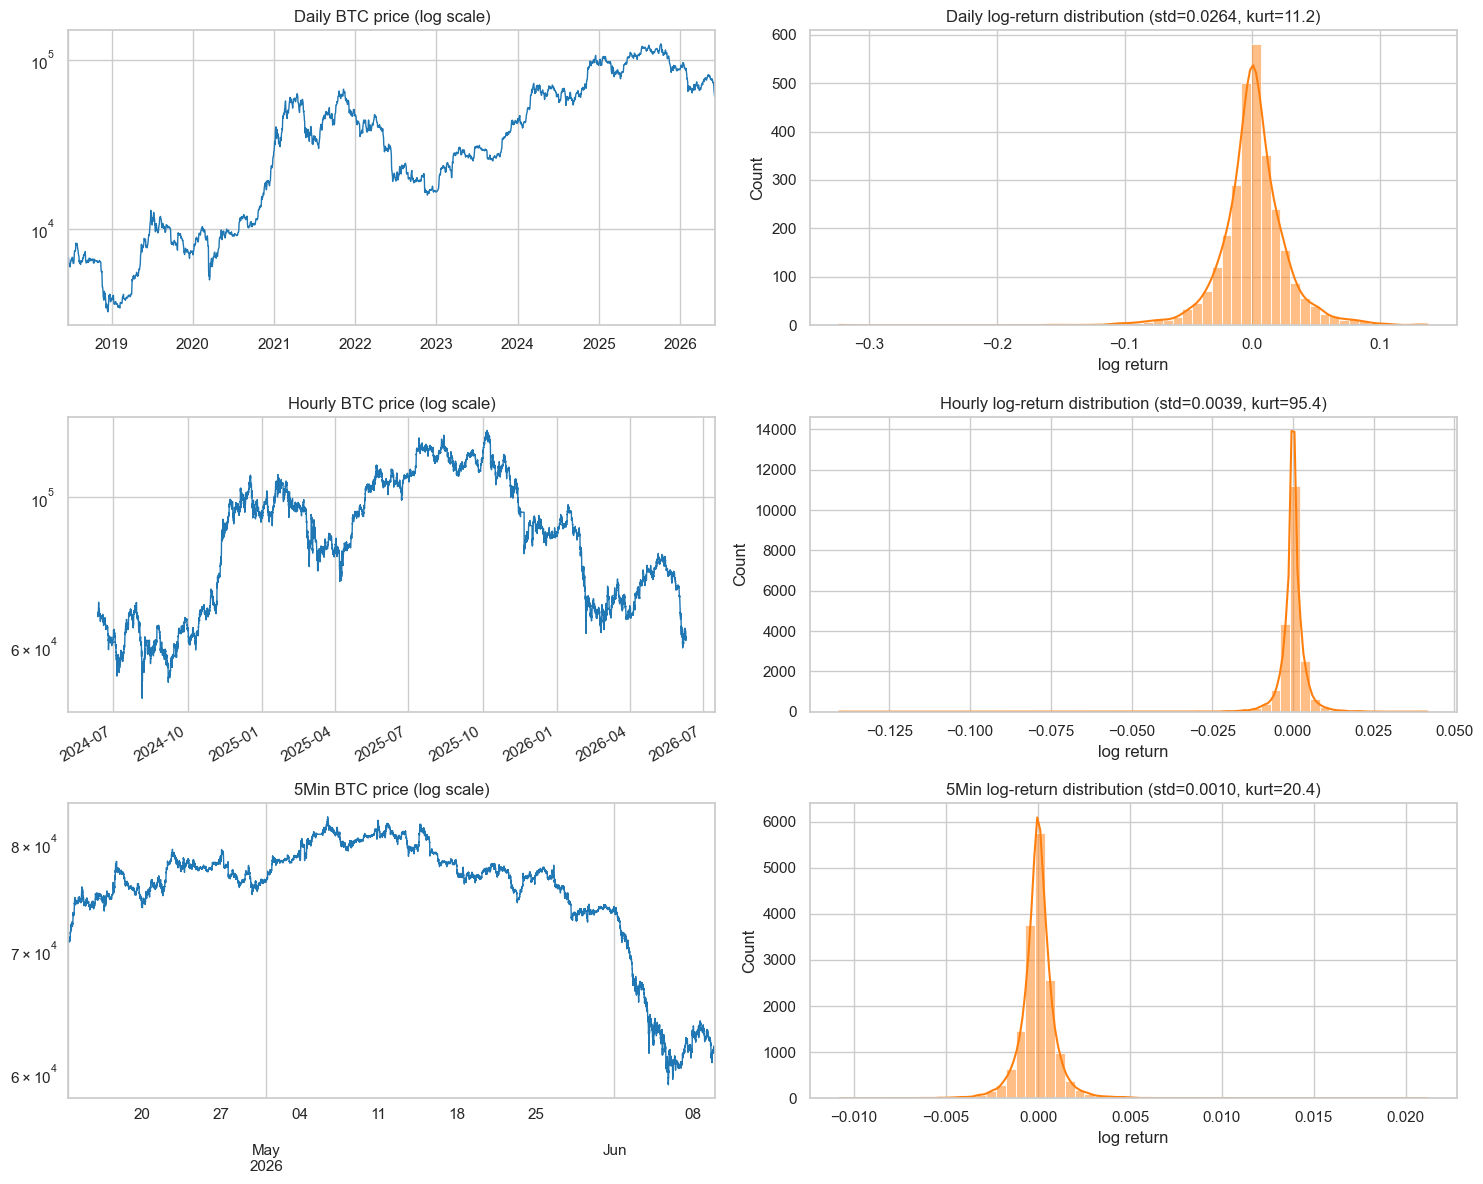

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for row, (frequency, df) in enumerate(datasets.items()):
    # Левая колонка: уровень цены в лог-шкале — виден мультипликативный тренд/режимы.
    df['BTC'].plot(ax=axes[row, 0], color='tab:blue', linewidth=1.0, logy=True)
    axes[row, 0].set_title(f'{frequency.title()} BTC price (log scale)')
    axes[row, 0].set_xlabel('')
    # Правая колонка: распределение лог-доходностей — целевая переменная моделей.
    # В отличие от уровня цены, доходности (около)стационарны и центрированы у нуля,
    # поэтому их распределение информативно (тяжёлые хвосты, эксцесс); гистограмма
    # самого уровня была бы лишь мультимодальным отражением ценовых режимов.
    logret = np.log(df['BTC']).diff().dropna()
    sns.histplot(logret, bins=60, kde=True, ax=axes[row, 1], color='tab:orange')
    axes[row, 1].set_title(f'{frequency.title()} log-return distribution '
                           f'(std={logret.std():.4f}, kurt={logret.kurt():.1f})')
    axes[row, 1].set_xlabel('log return')
plt.tight_layout()
plt.show()


### Missing Values and Outliers

The consolidated files contain no missing values. The modelling pipeline nonetheless applies median imputation so that the workflow remains robust to future data refreshes. Outliers are handled inside the training pipeline: numeric features are winsorised to train-fitted 1st and 99th percentiles before robust scaling, with all bounds estimated on the training fold only.

In [7]:
def iqr_outlier_count(frame):
    numeric = frame.select_dtypes(include=[np.number])
    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = numeric.lt(lower, axis=1) | numeric.gt(upper, axis=1)
    return mask.sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    frequency: df.isna().sum() for frequency, df in datasets.items()
}).fillna(0).astype(int)

display(missing_table.sum().rename('missing_values_by_frequency').to_frame())

outlier_rows = []
for frequency, df in datasets.items():
    counts = iqr_outlier_count(df).head(10)
    for feature, count in counts.items():
        outlier_rows.append({'frequency': frequency, 'feature': feature, 'IQR_outlier_count': int(count)})

display(pd.DataFrame(outlier_rows))


,missing_values_by_frequency
daily,0
hourly,0
5min,0


,frequency,feature,IQR_outlier_count
0,daily,Tether,604
1,daily,Initial_Jobless_Claims,581
2,daily,Unemployment_Rate,456
3,daily,XRP,411
4,daily,Platinum_Future,365
5,daily,Gold_Future,344
6,daily,MACD,323
7,daily,MicroStrategy,282
8,daily,TRON,272
9,daily,Natural_Gas_Future,271


## Methodology

The pipeline proceeds as follows.

1. Load the frozen daily, hourly, and 5-minute datasets and validate size, coverage, missing values, and feature groups.
2. Define the supervised task as one-step-ahead forecasting of the logarithmic return $r_t = \ln(P_t) - \ln(P_{t-1})$; for horizons $h>1$ the target is the cumulative forward return over $h$ bars.
3. Use strictly time-ordered splits with no shuffling. Models are evaluated by walk-forward validation with a rolling training window and a per-frequency retuning cadence.
4. Select features on the training portion only. A cross-fold stable selector ranks predictors by the median permutation importance (mean decrease in accuracy) across development folds and collapses collinear groups (clustered feature importance), which prevents look-ahead leakage and the substitution effect.
5. Fit all preprocessing on training data only: median imputation, 1st/99th-percentile winsorisation, and robust scaling.
6. Train, under the identical protocol: trivial and statistical baselines (zero-return, last-return, moving average, always-long, base-rate); three gradient-boosting regressors (LightGBM, XGBoost, CatBoost); and neural sequence models (LSTM and GRU) in both a regression and a weighted sign-classification variant, all built with the `CryptoNet` architecture.
7. Tune gradient-boosting hyperparameters per fold with Optuna inside a nested `PurgedKFold` (overlap purging and embargo), optimising a net-of-cost Sharpe objective.
8. Compare models by a composite criterion — the information-coefficient information ratio (IC IR), then net-of-cost Sharpe, then magnitude-weighted directional accuracy (MWDA), with MASE as a tie-breaker — rather than by raw directional accuracy.
9. Reconstruct the price path, run an economic backtest against Buy-and-Hold with transaction costs, and control for multiple testing with the Deflated Sharpe Ratio (DSR) and the Probability of Backtest Overfitting (PBO).

The central comparison is therefore **gradient-boosting ensembles versus neural networks**, evaluated at daily, hourly, and 5-minute granularities, with feature importance and shock-period error analysis providing the basis for interpretation.

In [8]:
import sys
sys.path.append(str(PROJECT_DIR))

from ml_models import (
    CryptoNetRegressor, _sample_crypto_hparams, run_optuna_study,
    set_global_seed, DEVICE,
)
set_global_seed(RANDOM_STATE)


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    ratio = np.divide(np.abs(y_true - y_pred), denominator, out=np.zeros_like(denominator), where=denominator != 0)
    return float(np.mean(ratio))


def mase(y_true, y_pred, y_train):
    y_train = np.asarray(y_train, dtype=float)
    scale = np.mean(np.abs(np.diff(y_train)))
    if scale == 0 or np.isnan(scale):
        return np.nan
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)


def regression_metrics(y_true, y_pred, y_train):
    frame = pd.concat([
        pd.Series(y_true, name='true'),
        pd.Series(y_pred, name='pred')
    ], axis=1).dropna()
    if frame.empty:
        return {'MAE': np.nan, 'RMSE': np.nan, 'MASE': np.nan, 'DA': np.nan}
    return {
        'MAE': mean_absolute_error(frame['true'], frame['pred']),
        'RMSE': np.sqrt(mean_squared_error(frame['true'], frame['pred'])),
        'MASE': mase(frame['true'], frame['pred'], y_train),
        # Directional Accuracy: доля совпадений знака (для таргета-доходности)
        'DA': float(np.mean((frame['true'].values > 0) == (frame['pred'].values > 0))),
    }


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)


def make_preprocessed_model(model, scale=True):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('clipper', QuantileClipper(lower=0.01, upper=0.99)),
    ]
    if scale:
        steps.append(('scaler', RobustScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


SMAPE_SCORER = make_scorer(smape, greater_is_better=False)


In [9]:
# Hardcoded configuration: feature shortlists and model hyperparameters.
#
# TOP_FEATURES — пул признаков-кандидатов для пофолдового top-k отбора (НЕ
# фиксированный шорт-лист). Пять прежних признаков уровня цены (BTC_lag*, BTC_mean5)
# заменены на признаки ДОХОДНОСТИ (ret_lag*, ret_mean5, ret_std10): таргет теперь —
# лог-доходность, и предикторы тоже должны быть стационарными (импульс/волатильность),
# иначе модель ключевается на нестационарном уровне цены. Все ret_*-признаки строго
# лагированы в prep_returns. Остальной пул — экзогенные ряды (уже лагированы в
# get_data) и RSI.
TOP_FEATURES = {
    'daily': [
        # признаки доходности (импульс / волатильность)
        'ret_lag1', 'ret_lag2', 'ret_lag5', 'ret_lag10',
        'ret_mean5', 'ret_mean10', 'ret_mean20', 'ret_std5', 'ret_std10', 'ret_std20',
        # тренд / возврат к среднему + нормированные технические + объём (OBV)
        'p_sma10', 'p_sma20', 'ema_cross', 'RSI', 'macd_norm', 'atr_pct', 'obv_chg',
        # настроения / риск-режим
        'fg_value', 'fg_chg', 'VIX',
        # экзогенные активы / индексы
        'SPDR_Communications', 'TRON', 'S&P_500', 'NASDAQ_100', 'MicroStrategy',
        'Gold_Future', 'XRP', 'ETH', 'Meta', 'NVIDIA',
        # time-of-day / календарные циклические признаки (T7.1, exog, без лага)
        'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    ],
    'hourly': [
        'ret_lag1', 'ret_lag2', 'ret_lag5', 'ret_lag10',
        'ret_mean5', 'ret_mean10', 'ret_mean20', 'ret_std5', 'ret_std10', 'ret_std20',
        'p_sma10', 'p_sma20', 'ema_cross', 'RSI', 'macd_norm', 'atr_pct', 'obv_chg', 'VIX',
        'XRP', 'TRON', 'Stellar', 'MicroStrategy', 'Litecoin', 'Meta',
        'SPDR_Financials', 'Amazon', 'Cardano', 'Chainlink',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',   # time-of-day (T7.1)
    ],
    '5min': [
        'ret_lag1', 'ret_lag2', 'ret_lag5', 'ret_lag10',
        'ret_mean5', 'ret_mean10', 'ret_mean20', 'ret_std5', 'ret_std10', 'ret_std20',
        'p_sma10', 'p_sma20', 'ema_cross', 'RSI', 'macd_norm', 'atr_pct', 'obv_chg', 'VIX',
        'MicroStrategy', 'Cardano', 'Dogecoin', 'Chainlink', 'Litecoin', 'XRP',
        'Amazon', 'Google', 'Ethereum_Classic',
        'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos',     # time-of-day (T7.1)
    ],
}

# Gradient boosting hyperparameters (structural params fixed; lr/n_est tuned per fold by Optuna).
GB_HYPERPARAMS = {
    'HistGradientBoosting': dict(
        max_iter=260, learning_rate=0.05, l2_regularization=0.05, random_state=RANDOM_STATE,
    ),
    'LightGBM': dict(
        n_estimators=320, learning_rate=0.03, num_leaves=31, min_child_samples=20,
        subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    'XGBoost': dict(
        objective='reg:squarederror', n_estimators=320, learning_rate=0.03, max_depth=3,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'CatBoost': dict(
        iterations=320, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
        random_state=RANDOM_STATE, verbose=False,
    ),
}

# Sequence-model (CryptoNet) per-frequency settings.
HOURLY_LONG_WINDOW = False   # T6.2: опц. удлинить hourly lookback 24 -> 48
NN_CONFIG = {
    'daily':  {'window_size': 24, 'epochs': 30, 'batch_size': 16},   # T6.2: 10 -> 24
    'hourly': {'window_size': 48 if HOURLY_LONG_WINDOW else 24, 'epochs': 25, 'batch_size': 32},
    '5min':   {'window_size': 24, 'epochs': 25, 'batch_size': 64},   # 5min: time-of-day (EPIC 7)
}
NN_ARCHITECTURES = ['LSTM', 'GRU']   # T7.6: убраны StackedLSTM/CNN_LSTM (дольше, результат хуже)
N_WORKERS = 7   # T7.6: параллельных процессов-прогонов (раскидываем по 36 ядрам; 1 = последовательно)
RUN_NN_CLF = True   # доп. дорожка: взвешенная классификация знака доходности (BCE)
STABLE_SELECTION = True     # T7.5: отбор фич = медиана MDA по dev-фолдам + CFI (вместо per-fold Pearson)
USE_FREE_FEATURES = False   # T7.4: подтянуть бесплатные order-flow/funding/basis/on-chain
                            # (Binance + Coin Metrics; требует сети при прогоне)
NN_OPTUNA_TRIALS = 5  # retained for reference; the experiment runs through walk-forward

# Walk-forward: КОРОТКИЕ скользящие окна с частым переобучением (борьба с дрейфом).
# train подобран так, чтобы у нейросетей оставалось достаточно окон-примеров, а test —
# короткий следующий блок. Optuna переобучается раз в RETUNE_EVERY фолдов (между ними —
# только refit), иначе сотни фолдов неподъёмны по времени.
#   daily : train 365 (~1 год) / test 21 (~1 мес)   -> ~108 фолдов (T6.1: 180->365)
#   hourly: train 504 (~3 нед) / test 48 (~2 дня)   -> ~425 фолдов, OOF ~98%
#   5min  : train 1440 (~5 дн) / test 288 (~1 день) -> ~52 фолда,  OOF ~92%
SPLIT_CONFIG = {
    'daily':  {'type': 'rolling', 'n_splits': None, 'train_size': 365,  'test_size': 21},
    'hourly': {'type': 'rolling', 'n_splits': None, 'train_size': 504,  'test_size': 48},
    '5min':   {'type': 'rolling', 'n_splits': None, 'train_size': 1440, 'test_size': 288},
}
# Ретюн-каденция по-частотная (T6.1): daily/5min раньше ретюнились почти фиктивно
# (~6-7 / ~2-3 раза) -> чаще; hourly оставлен 20.
RETUNE_EVERY = {'daily': 5, 'hourly': 20, '5min': 5}
WF_OPTUNA_TRIALS = 25      # GB: Optuna trials per (re)tune (расширенное HP-пространство, T3.2)
WF_NN_OPTUNA_TRIALS = 8    # NN: больше триалов под расширенную сетку (lr, weight_decay, размеры)
WF_TOP_K = 20   # features retained per fold via |Pearson| ranking on train fold only

# Annualisation constant for Sharpe ratio in backtest_summary
PERIODS_PER_YEAR = {'daily': 252, 'hourly': 8760, '5min': 105120}


In [10]:
# Подготовка датасетов под прогноз ДОХОДНОСТИ (а не уровня цены).
#
# Мотивация: уровень цены BTC нестационарен и трендовый. (1) Бустинги не
# экстраполируют за пределы диапазона таргета на трейне -> на растущем ряду они
# систематически недооценивают в поздних фолдах, что делает сравнение GB vs NN
# некорректным; (2) на уровне SMAPE вырождается до персистентности, а MASE
# завышается из-за смены ценового режима между трейном и тестом. Переход к
# лог-доходности r_t = log(P_t) - log(P_{t-1}) делает таргет (почти) стационарным:
# деревьям не нужно экстраполировать, метрики (включая Directional Accuracy) обретают
# смысл, а цена восстанавливается как P_t = P_{t-1} * exp(r_t).

from walk_forward import forward_log_return, add_cyclical_time_features

RET_LAGS = [1, 2, 5, 10]
# Контемпоранные BTC-производные из CSV посчитаны по "текущему" бару t и содержат
# BTC_t -> при прогнозе r_t это утечка. Сдвигаем их на 1 бар. Экзогенные ряды уже
# лагированы в get_data, календарные признаки известны заранее -> их НЕ трогаем.
CONTEMP_BTC_COLS = ['RSI', 'MACD', 'ATR', 'OBV', 'BTC_mean5', 'BTC_std10']


def prep_returns(df, feature_cols, horizon=1):
    """Фрейм для walk-forward с таргетом-лог-доходностью.

    Возвращает копию df, в которой:
      * BTC        - исходный уровень цены (для восстановления цены и графиков);
      * BTC_logret - целевая переменная r_t = log(P_t) - log(P_{t-1});
      * ret_lag*, ret_mean5, ret_std10 - строго лагированные (>= t-1) признаки
        доходности (импульс/волатильность), не содержащие r_t;
      * контемпоранные BTC-производные (RSI/MACD/ATR/OBV/BTC_mean5/BTC_std10)
        сдвинуты на 1 бар, чтобы исключить BTC_t.
    Признаки строятся уже с нужным лагом, поэтому в самом walk-forward
    дополнительный shift НЕ применяется (единый источник истины о зазоре).
    """
    out = df.copy()
    price = out['BTC'].astype(float)
    ret = np.log(price).replace([np.inf, -np.inf], np.nan).diff()   # 1-step r_t для фич
    # Таргет — forward кумулятивная доходность за `horizon` баров (T6.3); h=1 == ret.
    out['BTC_logret'] = forward_log_return(price, horizon)
    for L in RET_LAGS:
        out[f'ret_lag{L}'] = ret.shift(L)
    # Скользящие средние и волатильность доходностей на нескольких горизонтах
    # (импульс / режим волатильности); все строго лагированы (ret.shift(1)).
    for w in (5, 10, 20):
        out[f'ret_mean{w}'] = ret.shift(1).rolling(w).mean()
        out[f'ret_std{w}'] = ret.shift(1).rolling(w).std()
    # Цена относительно собственных скользящих средних (тренд / возврат к среднему)
    # и EMA-кроссовер; используется лагированная цена P_{t-1}.
    p_lag = price.shift(1)
    for w in (10, 20):
        out[f'p_sma{w}'] = p_lag / p_lag.rolling(w).mean() - 1
    out['ema_cross'] = (p_lag.ewm(span=5, adjust=False).mean()
                        / p_lag.ewm(span=20, adjust=False).mean() - 1)
    # Нормированные технические индикаторы (без зависимости от уровня цены) и
    # объёмный момент через OBV (сырого объёма в CSV нет — OBV суммирует объём).
    if 'MACD' in out.columns: out['macd_norm'] = (out['MACD'] / price).shift(1)
    if 'ATR' in out.columns: out['atr_pct'] = (out['ATR'] / price).shift(1)
    if 'OBV' in out.columns:
        _obv_d = out['OBV'].diff()
        # знаковый лог сжимает огромный объёмный масштаб OBV.diff() (до ~1e11) к ~[-27,27],
        # сохраняя порядок; иначе скейлер NN получает гигантские входы и обучение расходится.
        out['obv_chg'] = (np.sign(_obv_d) * np.log1p(_obv_d.abs())).shift(1)
    # Индекс страха и жадности — присутствует только в дневных данных.
    if 'Feer_Greed_value' in out.columns:
        out['fg_value'] = out['Feer_Greed_value'].shift(1)
        out['fg_chg'] = out['Feer_Greed_value'].diff().shift(1)
    # Контемпоранные BTC-производные содержат BTC_t -> сдвигаем на 1 бар.
    present = [c for c in CONTEMP_BTC_COLS if c in out.columns]
    out[present] = out[present].shift(1)
    # Time-of-day / календарные циклические признаки (T7.1): детерминированы по
    # прогнозируемому timestamp -> НЕ лагируются (утечки нет), идут в exog-ветку.
    out = add_cyclical_time_features(out)
    needed = list(dict.fromkeys(list(feature_cols) + ['BTC', 'BTC_logret']))
    return out.dropna(subset=needed)


wf_frames = OrderedDict(
    (freq, prep_returns(datasets[freq], TOP_FEATURES[freq],
                        horizon=DATA_CONFIG[freq].get('horizon', 1)))
    for freq in DATA_CONFIG
)

# --- T7.4: опциональные БЕСПЛАТНЫЕ exog-фичи (order-flow / funding / basis / on-chain) ---
# По умолчанию ВЫКЛ (нужна сеть). Фичи лагируются у источника (lag=1) -> анти-утечка;
# all-NaN не добавляются. FEATURE_POOL[freq] = TOP_FEATURES[freq] (+ собранные free).
FEATURE_POOL = {f: list(TOP_FEATURES[f]) for f in DATA_CONFIG}
if USE_FREE_FEATURES:
    from free_features import attach_free_features, FREE_FEATURE_NAMES
    for f in DATA_CONFIG:
        aug = attach_free_features(wf_frames[f], f, lag=1)
        free = [c for c in FREE_FEATURE_NAMES if c in aug.columns]
        if free:
            wf_frames[f] = aug.dropna(subset=free)
            FEATURE_POOL[f] = list(TOP_FEATURES[f]) + free
            print(f'[free] {f}: +{len(free)} фич {free} -> {len(wf_frames[f])} строк')
        else:
            print(f'[free] {f}: фич не добавлено (нет сети/данных) — без изменений')

# Сводка по подготовленным фреймам и пулу признаков-кандидатов.
split_summary = pd.DataFrame([
    {
        'frequency': freq,
        'rows': len(frame),
        'start': frame.index.min(),
        'end': frame.index.max(),
        'logret_mean': frame['BTC_logret'].mean(),
        'logret_std': frame['BTC_logret'].std(),
        'candidate_features': len(TOP_FEATURES[freq]),
    }
    for freq, frame in wf_frames.items()
])

feature_table = pd.DataFrame([
    {'frequency': freq, 'rank': rank, 'feature': feat}
    for freq in wf_frames
    for rank, feat in enumerate(TOP_FEATURES[freq], start=1)
])

display(split_summary)
display(feature_table)


,frequency,rows,start,end,logret_mean,logret_std,candidate_features
0,daily,2891,2018-07-11 00:00:00,2026-06-09 00:00:00,0.000783,0.026431,34
1,hourly,20901,2024-06-12 05:00:00,2026-06-09 23:00:00,-0.000004,0.003861,32
2,5min,16568,2026-04-13 11:20:00,2026-06-09 23:55:00,-0.000008,0.001021,31


,frequency,rank,feature
0,daily,1,ret_lag1
1,daily,2,ret_lag2
2,daily,3,ret_lag5
3,daily,4,ret_lag10
4,daily,5,ret_mean5
...,...,...,...
92,5min,27,Ethereum_Classic
93,5min,28,tod_sin
94,5min,29,tod_cos
95,5min,30,dow_sin


## Return Autocorrelation and the Economics of Transaction Costs

The look-back and training windows and the forecasting horizon are chosen from the data rather than from round numbers. The look-back is informed by the extent of significant autocorrelation in the return series (ACF/PACF), and the horizon is justified by comparing the median absolute return with the round-trip transaction cost, so that the expected move is large enough to be tradable net of costs.

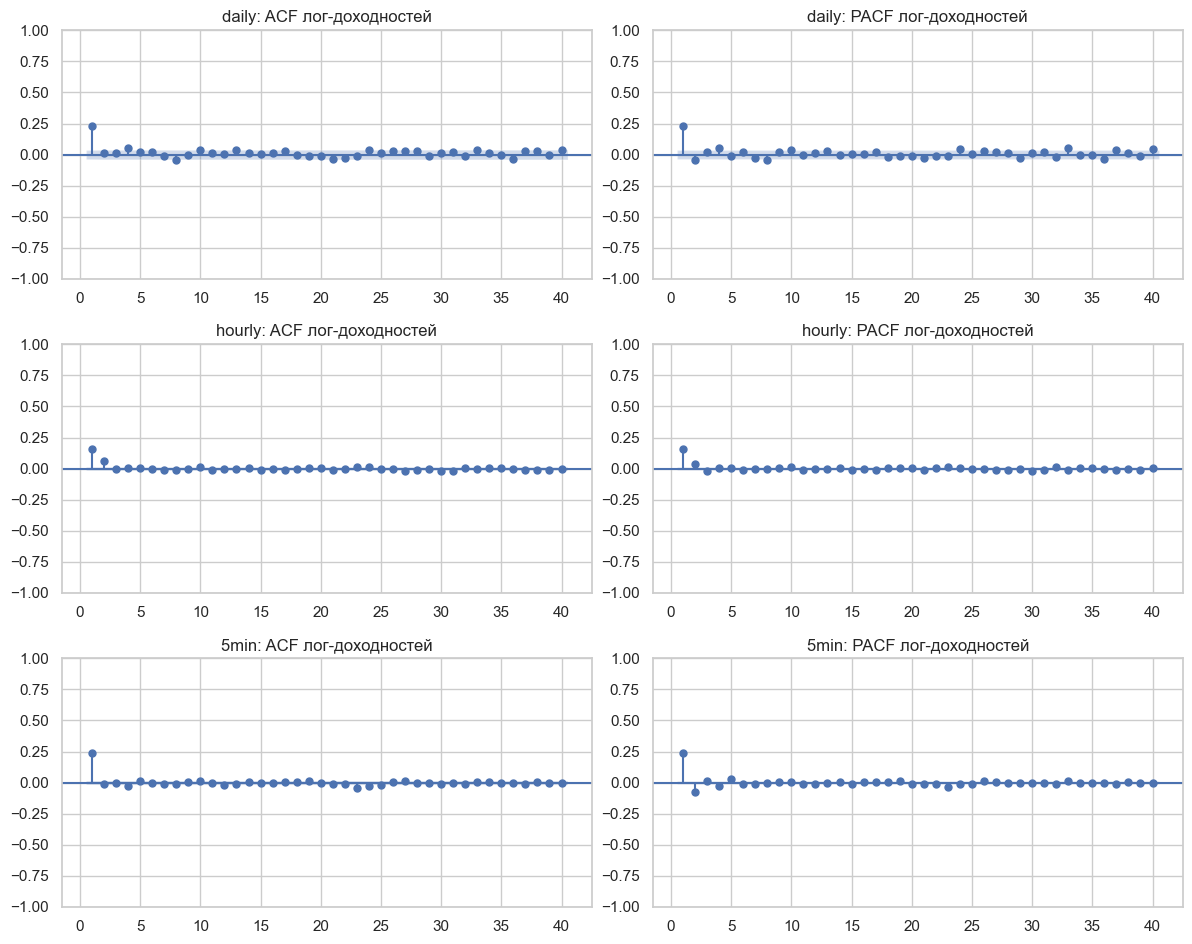

Окна/горизонт — по ACF/PACF (значимая автокорреляция) и по экономике издержек.
Если median|r| <= round-trip cost, одношаговая ставка структурно нерентабельна -> рассмотреть горизонт h>1 (DATA_CONFIG[freq]["horizon"]).


,frequency,median_abs_r,round_trip_cost,median|r|/RTC,tradeable_1step
0,daily,0.011624,0.0014,8.303,True
1,hourly,0.001285,0.0014,0.918,False
2,5min,0.000418,0.0014,0.298,False


In [11]:
# =====================================================================
# EPIC 6 / T6.4 — выбор окон и горизонта ПО ДАННЫМ:
# ACF/PACF доходностей + сравнение median(|r|) с round-trip издержками.
# =====================================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from backtest import round_trip_cost

_RTC = round_trip_cost(0.0005, 2.0)
cost_rows = []
fig, axes = plt.subplots(len(wf_frames), 2, figsize=(12, 3.2 * len(wf_frames)))
if len(wf_frames) == 1:
    axes = axes.reshape(1, 2)
for i, (freq, frame) in enumerate(wf_frames.items()):
    r = frame['BTC_logret'].dropna()
    lags = max(5, min(40, len(r) // 2 - 1))
    plot_acf(r, ax=axes[i, 0], lags=lags, zero=False)
    axes[i, 0].set_title(f'{freq}: ACF лог-доходностей')
    plot_pacf(r, ax=axes[i, 1], lags=lags, method='ywm', zero=False)
    axes[i, 1].set_title(f'{freq}: PACF лог-доходностей')
    med_abs = float(r.abs().median())
    cost_rows.append({'frequency': freq, 'median_abs_r': med_abs, 'round_trip_cost': _RTC,
                      'median|r|/RTC': med_abs / _RTC, 'tradeable_1step': med_abs > _RTC})
plt.tight_layout(); plt.show()
cost_table = pd.DataFrame(cost_rows)
print('Окна/горизонт — по ACF/PACF (значимая автокорреляция) и по экономике издержек.')
print('Если median|r| <= round-trip cost, одношаговая ставка структурно нерентабельна '
      '-> рассмотреть горизонт h>1 (DATA_CONFIG[freq]["horizon"]).')
display(cost_table.round({'median_abs_r': 6, 'round_trip_cost': 6, 'median|r|/RTC': 3}))

## Experiment Setup and Results

All models are evaluated on identical, strictly time-ordered walk-forward splits at each frequency. Gradient-boosting and baseline models use the leakage-safe stable feature selection described above, and gradient-boosting hyperparameters are tuned per fold by Optuna within a purged cross-validation. The LSTM and GRU architectures use a windowed sequence representation of past returns together with an exogenous-feature branch, with hyperparameters chosen per architecture and frequency by a small Optuna search and with `RobustScaler` fitted on training data only. No baseline or model uses future observations; all imputers, winsorisation bounds, and scalers are estimated on the training fold alone.

In [12]:
def build_model_specs():
    """Gradient boosting candidates only, with hardcoded hyperparameters."""
    specs = OrderedDict()

    # T7.6: HistGradientBoosting убран (медленнее тюнится, результат не лучше).
    if HAS_LIGHTGBM:
        specs['LightGBM'] = make_preprocessed_model(
            LGBMRegressor(**GB_HYPERPARAMS['LightGBM']),
            scale=False,
        )

    if HAS_XGBOOST:
        specs['XGBoost'] = make_preprocessed_model(
            XGBRegressor(**GB_HYPERPARAMS['XGBoost']),
            scale=False,
        )

    if HAS_CATBOOST:
        specs['CatBoost'] = make_preprocessed_model(
            CatBoostRegressor(**GB_HYPERPARAMS['CatBoost']),
            scale=False,
        )

    return specs


In [13]:
import os
import time as _time
from sklearn.base import clone

from walk_forward import (
    expanding_window_splits, rolling_window_splits, run_walk_forward,
    select_best_by_composite, select_stable_features,
)
from backtest import simulate_strategy, buy_and_hold, backtest_summary, round_trip_cost
from parallel_run import build_run_specs, run_specs_parallel
from ml_models import compute_metrics
from metrics import rank_ic, ic_ir, mwda, mcc, balanced_accuracy, net_cost_sharpe

TARGET = 'BTC_logret'


def _family(name):
    if 'sign clf' in name:
        return 'NN_CLF'
    if any(a in name for a in ('LSTM', 'GRU', 'CNN_LSTM', 'StackedLSTM')):
        return 'NN'
    if name in ('Naive (zero return)', 'Last return', 'Moving average',
                'Always long', 'Base rate'):
        return 'baseline'
    return 'GB'


def _get_splits(frequency, cfg, n):
    if cfg['type'] == 'expanding':
        return expanding_window_splits(n, cfg['n_splits'], cfg['min_train_frac'])
    return rolling_window_splits(n, cfg['train_size'], cfg['test_size'], n_splits=cfg['n_splits'])


def make_gb_factory(model_template):
    """Zero-arg callable producing a fresh clone of model_template."""
    def factory():
        return clone(model_template)
    return factory


def reconstruct_price_oof(oof_ret_df, price, horizon=1):
    """Восстановление цены из прогноза доходности: P_hat = P_{t-1} * exp(r_hat).

    oof_ret_df - OOF в пространстве доходностей (actual/predicted = лог-доходности).
    price      - полный ряд уровня цены BTC (datasets[freq]['BTC']).
    horizon    - при h>1 predicted = forward кумулятивная доходность (T6.3): и предсказание,
                 и факт восстанавливаются как цена КОНЦА горизонта (P_{t-1}*exp(R)). Бэктест
                 при h>1 использует min_hold>=h. TODO: корректный учёт перекрытия позиций.
    Возвращает OOF в пространстве цены для экономического бэктеста.
    """
    prev_price = price.shift(1)
    rows = []
    for model_name, grp in oof_ret_df.groupby('model'):
        grp = grp.sort_values('timestamp')
        p_prev = prev_price.reindex(grp['timestamp']).to_numpy(dtype=float)
        # клип прогноза доходности перед exp: защита от переполнения, если модель
        # разойдётся на коротком фолде (|r_hat| > 1 экономически нереалистично).
        r_hat = np.clip(grp['predicted'].to_numpy(dtype=float), -1.0, 1.0)
        p_pred = p_prev * np.exp(r_hat)
        if horizon == 1:
            p_actual = price.reindex(grp['timestamp']).to_numpy(dtype=float)
        else:
            r_act = np.clip(grp['actual'].to_numpy(dtype=float), -10.0, 10.0)
            p_actual = p_prev * np.exp(r_act)
        rows.append(pd.DataFrame({
            'timestamp': grp['timestamp'].values,
            'actual': p_actual,
            'predicted': p_pred,
            'fold': grp['fold'].values,
            'model': model_name,
        }))
    return pd.concat(rows, ignore_index=True)


wf_metrics_all = {}      # freq -> per-fold metrics (return space)
wf_oof_all = {}          # freq -> OOF predictions (return space)
wf_oof_price_all = {}    # freq -> OOF reconstructed to price (for the backtest)

INNER_THREADS = max(1, (os.cpu_count() or 8) // max(1, N_WORKERS))  # потоков на воркер
t_wf_start = _time.time()

for frequency, df_freq in wf_frames.items():
    print(f'\n=== Walk-forward: {frequency} (target = log-return) ===')

    n = len(df_freq)
    cfg = SPLIT_CONFIG[frequency]
    splits = _get_splits(frequency, cfg, n)
    nn_cfg = NN_CONFIG[frequency]
    freq_horizon = DATA_CONFIG[frequency].get('horizon', 1)
    # T7.5: стабильный отбор фич — медиана MDA по dev-фолдам + CFI (leakage-safe:
    # важность считается на dev-префиксе, набор фиксируется). Иначе — весь пул
    # (per-fold |Pearson| внутри run_walk_forward как раньше).
    _pool = FEATURE_POOL[frequency]
    if STABLE_SELECTION:
        feat_pool = select_stable_features(df_freq, _pool, TARGET, splits,
                                           k=min(WF_TOP_K, len(_pool)),
                                           method='mda', corr_threshold=0.9)
        print(f'  [select] {frequency}: stable MDA+CFI -> {len(feat_pool)} фич')
    else:
        feat_pool = _pool
    pool_topk = len(feat_pool)

    freq_metrics_list = []
    freq_oof_list = []

    # 1-2b. GB + NN + NN_CLF прогоны НЕЗАВИСИМЫ -> параллельно по процессам (T7.6):
    # раскидываем по N_WORKERS воркеров (joblib/loky), каждому лимит INNER_THREADS.
    specs = build_run_specs(
        frequency, df_freq, TARGET, feat_pool, splits, top_k=pool_topk,
        gb_templates=build_model_specs(), nn_archs=NN_ARCHITECTURES, run_clf=RUN_NN_CLF,
        nn_config=nn_cfg, seed=RANDOM_STATE, retune_every=RETUNE_EVERY[frequency],
        gb_trials=WF_OPTUNA_TRIALS, nn_trials=WF_NN_OPTUNA_TRIALS, horizon=freq_horizon,
        inner_threads=INNER_THREADS,
    )
    print(f'  {frequency}: {len(specs)} прогонов в {N_WORKERS} воркеров (по {INNER_THREADS} потоков)...', flush=True)
    t0 = _time.time()
    for _name, mdf, odf in run_specs_parallel(specs, n_workers=N_WORKERS):
        freq_metrics_list.append(mdf)
        freq_oof_list.append(odf)
    print(f'  готово за {_time.time()-t0:.0f}s')

    # 3. Baselines in return space:
    #    Naive (zero return) -> r_hat = 0   (бенчмарк "случайное блуждание цены")
    #    Last return         -> r_hat_t = r_{t-1}   (персистентность доходности)
    #    Moving average      -> скользящее среднее прошлых доходностей
    #    Always long         -> r_hat = +eps   (всегда длинная позиция; DA = base-rate up)
    #    Base rate           -> знак мажоритарного класса доходности на трейне (T3.4)
    ret = df_freq[TARGET]
    ma_window = DATA_CONFIG[frequency]['ma_window']
    EPS_DIR = 1e-6
    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        actual = ret.iloc[test_idx]
        y_tr = ret.iloc[train_idx].to_numpy(dtype=float)
        base_up = float(np.mean(y_tr > 0)) if y_tr.size else 0.5
        base_sign = EPS_DIR if base_up >= 0.5 else -EPS_DIR
        preds = {
            'Naive (zero return)': pd.Series(0.0, index=actual.index),
            'Last return': ret.shift(1).iloc[test_idx],
            'Moving average': ret.shift(1).rolling(ma_window, min_periods=1).mean().iloc[test_idx],
            'Always long': pd.Series(EPS_DIR, index=actual.index),
            'Base rate': pd.Series(base_sign, index=actual.index),
        }
        for bname, bpred in preds.items():
            ba = actual.to_numpy(dtype=float)
            bp = bpred.to_numpy(dtype=float)
            m = compute_metrics(ba, bp, y_tr)
            is_dir = bname in ('Always long', 'Base rate')
            freq_metrics_list.append(pd.DataFrame([{
                'fold': fold_idx, 'model': bname,
                'MAE': m['mae'], 'RMSE': m['rmse'], 'SMAPE': m['smape'],
                'MASE': m['mase'], 'DA': m['da'],
                'RankIC': rank_ic(ba, bp), 'MWDA': mwda(ba, bp),
                'MCC': mcc(ba, bp) if is_dir else np.nan,
                'BalAcc': balanced_accuracy(ba, bp) if is_dir else np.nan,
                'n_train': len(train_idx), 'n_test': len(test_idx),
            }]))
            freq_oof_list.append(pd.DataFrame({
                'timestamp': actual.index, 'actual': ba,
                'predicted': bp, 'fold': fold_idx, 'model': bname,
            }))

    wf_metrics_all[frequency] = pd.concat(freq_metrics_list, ignore_index=True)
    wf_oof_all[frequency] = pd.concat(freq_oof_list, ignore_index=True)
    wf_oof_price_all[frequency] = reconstruct_price_oof(
        wf_oof_all[frequency], datasets[frequency]['BTC'], horizon=freq_horizon
    )

print(f'\nTotal walk-forward time: {_time.time()-t_wf_start:.0f}s')

# Aggregate (mean across folds) + composite-selection metrics (EPIC 3, T3.1).
# Ведущая метрика селекции — IC IR (стабильность Rank IC по фолдам), затем
# net-of-cost Sharpe, затем MWDA; tie-break MASE. (Раньше — «голая» DA.)
RTC_FEE = round_trip_cost(0.0005, 2.0)   # ~0.14% round-trip для net-of-cost Sharpe
agg_frames = []
for freq, mdf in wf_metrics_all.items():
    metric_cols = [c for c in ['MAE', 'RMSE', 'MASE', 'DA', 'RankIC', 'MWDA', 'MCC', 'BalAcc', 'AUC']
                   if c in mdf.columns]
    agg = mdf.groupby('model')[metric_cols].mean().reset_index()
    # IC IR = mean(IC)/std(IC) по фолдам (стабильность), НЕ среднее IC.
    ic_ir_by_model = mdf.groupby('model')['RankIC'].apply(lambda s: ic_ir(s.dropna().tolist()))
    agg['IC_IR'] = agg['model'].map(ic_ir_by_model)
    # net-of-cost Sharpe в return-space: side = sign(r_hat), издержки на оборот позиции.
    oof = wf_oof_all[freq]
    ncs = {}
    for mname, grp in oof.groupby('model'):
        g = grp.sort_values('timestamp')
        ncs[mname] = net_cost_sharpe(np.sign(g['predicted'].to_numpy(dtype=float)),
                                     g['actual'].to_numpy(dtype=float), fee=RTC_FEE)
    agg['NetSharpe'] = agg['model'].map(ncs)
    agg['frequency'] = freq
    agg['family'] = agg['model'].apply(_family)
    agg_frames.append(agg)
wf_agg = pd.concat(agg_frames, ignore_index=True)

_gb_names = set(build_model_specs().keys())
_nn_names = {f'{a} (sequence NN)' for a in NN_ARCHITECTURES}
_clf_names = {f'{a} (sign clf)' for a in NN_ARCHITECTURES}


def _best_by_composite(names):
    # Делегирует в импортируемую walk_forward.select_best_by_composite (тестируемо):
    # IC IR -> net-of-cost Sharpe -> MWDA, tie-break MASE asc (EPIC 3, T3.1).
    return select_best_by_composite(wf_agg, names)


best_gb = _best_by_composite(_gb_names)
best_nn = _best_by_composite(_nn_names)
best_nn_clf = _best_by_composite(_clf_names)   # пусто, если RUN_NN_CLF=False

# Price-space continuity metrics (SMAPE/MAE on reconstructed price) for comparability
# with the prior level-target report. SMAPE is well-defined here (prices > 0).
price_metric_rows = []
for freq, pdf in wf_oof_price_all.items():
    for model_name, grp in pdf.groupby('model'):
        if _family(model_name) == 'NN_CLF':
            continue  # классификатор не предсказывает уровень цены -> SMAPE_price не определён
        g = grp.dropna(subset=['actual', 'predicted'])
        if g.empty:
            continue
        price_metric_rows.append({
            'frequency': freq, 'model': model_name, 'family': _family(model_name),
            'SMAPE_price': 100 * smape(g['actual'].values, g['predicted'].values),
            'MAE_price': mean_absolute_error(g['actual'], g['predicted']),
        })
price_metrics = pd.DataFrame(price_metric_rows)

# Refit best GB / NN on the LAST fold's train data, on the SAME shifted return frame
# used by walk-forward (no raw-price leakage) -> interpretation matches evaluation.
refit_gb = {}
for _, row in best_gb.iterrows():
    freq, mname = row['frequency'], row['model']
    frame = wf_frames[freq]
    last_train_idx = _get_splits(freq, SPLIT_CONFIG[freq], len(frame))[-1][0]
    X_last = frame[TOP_FEATURES[freq]].iloc[last_train_idx]
    y_last = frame[TARGET].iloc[last_train_idx]
    m = clone(build_model_specs()[mname])
    m.fit(X_last, y_last)
    refit_gb.setdefault(freq, {})[mname] = m

refit_nn = {}
hp_map = {
    'LSTM': {'lstm_units': 64, 'lstm_drop': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
    'GRU': {'gru_units': 64, 'gru_drop': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
    'StackedLSTM': {'stacked_layers': 2, 'stack_units_0': 64, 'stack_drop_0': 0.2, 'stack_units_1': 64, 'stack_drop_1': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
    'CNN_LSTM': {'cnn_kernel': 3, 'pool_size': 2, 'cnn_filters': 32, 'cnn_drop': 0.2, 'cnn_lstm_units': 64, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
}
for _, row in best_nn.iterrows():
    freq, mname = row['frequency'], row['model']
    arch = mname.split()[0]
    nn_cfg = NN_CONFIG[freq]
    frame = wf_frames[freq]
    last_train_idx = _get_splits(freq, SPLIT_CONFIG[freq], len(frame))[-1][0]
    seq_cols = TOP_FEATURES[freq] + [TARGET]
    seq_train_df = frame[seq_cols].iloc[last_train_idx]
    reg = CryptoNetRegressor(
        arch=arch, target_col=TARGET, feature_cols=TOP_FEATURES[freq],
        window_size=nn_cfg['window_size'], hp=hp_map[arch],
        lr=1e-3, epochs=nn_cfg['epochs'], batch_size=nn_cfg['batch_size'],
        patience=5, seed=RANDOM_STATE,
    )
    reg.fit(seq_train_df)
    refit_nn.setdefault(freq, {})[mname] = reg

# prediction_store: OOF predictions (RETURN space) + fitted model for interpretation cells.
prediction_store = OrderedDict()
for freq, oof_df in wf_oof_all.items():
    prediction_store[freq] = {}
    for model_name, grp in oof_df.groupby('model'):
        grp = grp.sort_values('timestamp')
        fitted_obj = refit_gb.get(freq, {}).get(model_name) or refit_nn.get(freq, {}).get(model_name)
        prediction_store[freq][model_name] = {
            'test_pred': pd.Series(grp['predicted'].values, index=grp['timestamp']),
            'train_pred': pd.Series(dtype=float),
            'model': fitted_obj,
        }

results_df = wf_agg.copy()
results_df['comment'] = 'Walk-forward OOF mean across folds (log-return target)'


=== Walk-forward: daily (target = log-return) ===


  [select] daily: stable MDA+CFI -> 20 фич
  daily: 7 прогонов в 7 воркеров (по 10 потоков)...
  готово за 1952s

=== Walk-forward: hourly (target = log-return) ===
  [select] hourly: stable MDA+CFI -> 20 фич
  hourly: 7 прогонов в 7 воркеров (по 10 потоков)...
  готово за 2183s

=== Walk-forward: 5min (target = log-return) ===
  [select] 5min: stable MDA+CFI -> 19 фич
  5min: 7 прогонов в 7 воркеров (по 10 потоков)...
  готово за 1189s

Total walk-forward time: 5423s


Walk-forward per-fold metrics (target = log-return):

--- daily ---


,fold,model,MAE,RMSE,MASE,DA,AUC,n_train,n_test
843,0,Always long,0.029578,0.037765,1.2188,0.4286,NaN,365,21
848,1,Always long,0.020904,0.029529,0.8249,0.5714,NaN,365,21
853,2,Always long,0.014764,0.019795,0.5859,0.4286,NaN,365,21
858,3,Always long,0.015007,0.027432,0.5943,0.3810,NaN,365,21
863,4,Always long,0.013581,0.018826,0.5327,0.4286,NaN,365,21
...,...,...,...,...,...,...,...,...,...
235,115,XGBoost,0.017550,0.024384,1.0563,0.6190,NaN,365,21
236,116,XGBoost,0.015054,0.018046,0.9202,0.6190,NaN,365,21
237,117,XGBoost,0.015630,0.018616,0.9620,0.3333,NaN,365,21
238,118,XGBoost,0.008208,0.010089,0.5127,0.6667,NaN,365,21



--- hourly ---


,fold,model,MAE,RMSE,MASE,DA,AUC,n_train,n_test
2971,0,Always long,0.001635,0.002906,0.5949,0.4792,NaN,504,48
2976,1,Always long,0.001815,0.002799,0.7070,0.3542,NaN,504,48
2981,2,Always long,0.003428,0.005027,1.3479,0.3750,NaN,504,48
2986,3,Always long,0.003597,0.006052,1.2486,0.5000,NaN,504,48
2991,4,Always long,0.003880,0.005775,1.2508,0.5208,NaN,504,48
...,...,...,...,...,...,...,...,...,...
843,419,XGBoost,0.001689,0.002307,0.6890,0.6875,NaN,504,48
844,420,XGBoost,0.003145,0.004628,1.3270,0.7500,NaN,504,48
845,421,XGBoost,0.004203,0.006261,1.5953,0.7083,NaN,504,48
846,422,XGBoost,0.005010,0.006926,1.6837,0.4167,NaN,504,48



--- 5min ---


,fold,model,MAE,RMSE,MASE,DA,AUC,n_train,n_test
367,0,Always long,0.000506,0.000678,0.5179,0.5000,NaN,1440,288
372,1,Always long,0.000743,0.001054,0.8387,0.5174,NaN,1440,288
377,2,Always long,0.000724,0.000983,0.8229,0.5000,NaN,1440,288
382,3,Always long,0.000814,0.001247,0.9288,0.5278,NaN,1440,288
387,4,Always long,0.000657,0.000882,0.7529,0.5243,NaN,1440,288
...,...,...,...,...,...,...,...,...,...
99,47,XGBoost,0.001529,0.002044,1.3945,0.5451,NaN,1440,288
100,48,XGBoost,0.001637,0.002276,1.1797,0.5868,NaN,1440,288
101,49,XGBoost,0.000823,0.001074,0.4888,0.4653,NaN,1440,288
102,50,XGBoost,0.001094,0.001853,0.6491,0.4792,NaN,1440,288




Walk-forward aggregate (mean across folds, sorted by IC IR — composite lead):


,frequency,model,family,MASE,DA,IC_IR,RankIC,MWDA,NetSharpe,MCC,BalAcc,AUC
31,5min,Last return,baseline,1.0500,0.5799,4.124,0.2083,0.6206,-0.609,NaN,NaN,NaN
27,5min,GRU (sequence NN),NN,0.8268,0.5554,3.571,0.1991,0.5973,-0.612,NaN,NaN,NaN
28,5min,GRU (sign clf),NN_CLF,NaN,0.5668,3.429,0.1997,0.6029,-0.568,0.1425,0.5649,0.5988
29,5min,LSTM (sequence NN),NN,0.8299,0.5603,3.162,0.1941,0.5981,-0.608,NaN,NaN,NaN
30,5min,LSTM (sign clf),NN_CLF,NaN,0.5541,2.771,0.1912,0.6006,-0.542,0.1219,0.5557,0.5957
35,5min,XGBoost,GB,0.8590,0.5421,2.467,0.1663,0.5791,-0.436,NaN,NaN,NaN
26,5min,CatBoost,GB,0.8819,0.5369,2.062,0.1661,0.5716,-0.416,NaN,NaN,NaN
32,5min,LightGBM,GB,0.8659,0.5433,1.942,0.1546,0.5728,-0.463,NaN,NaN,NaN
33,5min,Moving average,baseline,0.8839,0.5123,0.043,0.0025,0.5295,-0.209,NaN,NaN,NaN
24,5min,Always long,baseline,0.8328,0.4905,NaN,NaN,0.4953,-0.013,0.0000,0.5000,NaN


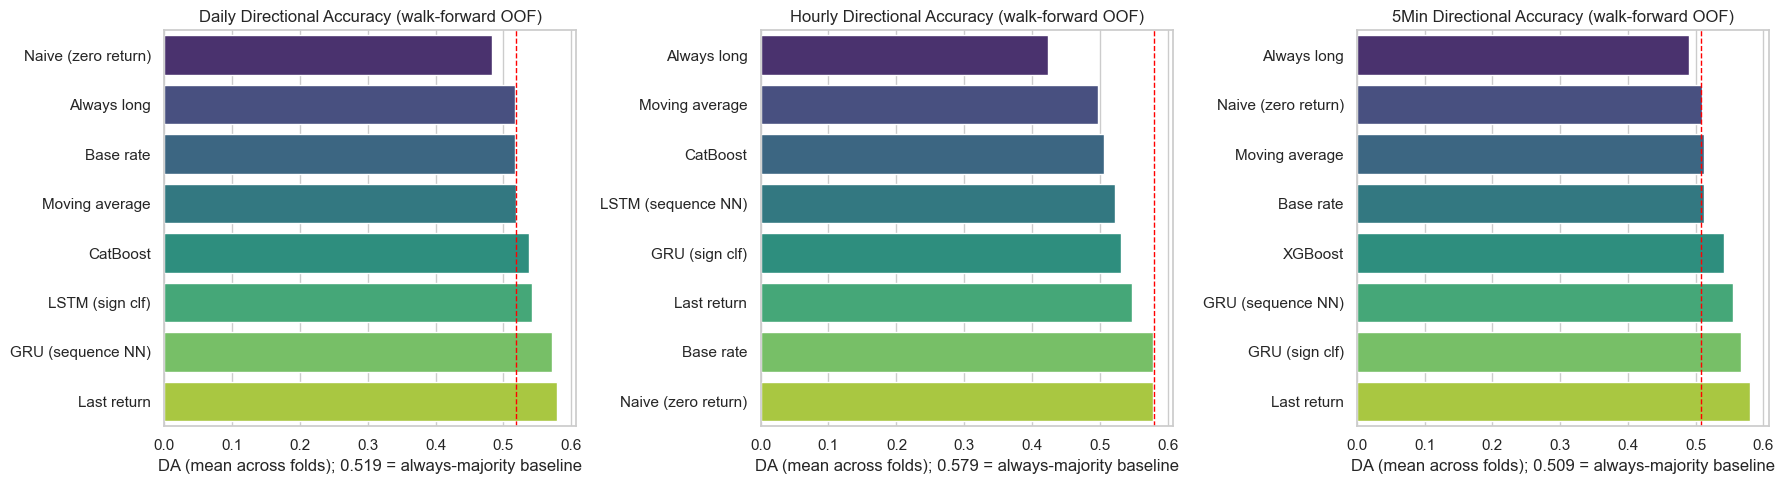

Best model per family by composite (IC IR -> NetSharpe -> MWDA; incl. sign clf):


,frequency,model,family,MASE,DA,IC_IR,MWDA,NetSharpe,MCC,BalAcc,AUC
0,5min,Last return,baseline,1.0500,0.5799,4.124,0.6206,-0.609,NaN,NaN,NaN
1,5min,GRU (sign clf),NN_CLF,NaN,0.5668,3.429,0.6029,-0.568,0.1425,0.5649,0.5988
2,5min,GRU (sequence NN),NN,0.8268,0.5554,3.571,0.5973,-0.612,NaN,NaN,NaN
3,5min,XGBoost,GB,0.8590,0.5421,2.467,0.5791,-0.436,NaN,NaN,NaN
4,5min,Base rate,baseline,0.8327,0.5124,NaN,0.4989,0.004,0.0000,0.5000,NaN
5,5min,Moving average,baseline,0.8839,0.5123,0.043,0.5295,-0.209,NaN,NaN,NaN
6,5min,Naive (zero return),baseline,0.8327,0.5095,NaN,0.0000,NaN,NaN,NaN,NaN
7,5min,Always long,baseline,0.8328,0.4905,NaN,0.4953,-0.013,0.0000,0.5000,NaN
8,daily,Last return,baseline,0.9768,0.5786,0.965,0.6276,0.139,NaN,NaN,NaN
9,daily,GRU (sequence NN),NN,0.7375,0.5710,0.904,0.6004,0.111,NaN,NaN,NaN




Reconstructed-price error (continuity with prior report):


,frequency,model,family,SMAPE_price,MAE_price
23,5min,GRU (sequence NN),NN,0.0636,46.72
21,5min,Base rate,baseline,0.0638,46.94
28,5min,Naive (zero return),baseline,0.0638,46.94
20,5min,Always long,baseline,0.0638,46.94
24,5min,LSTM (sequence NN),NN,0.0642,47.12
29,5min,XGBoost,GB,0.0655,48.30
26,5min,LightGBM,GB,0.0660,48.62
22,5min,CatBoost,GB,0.0671,49.53
27,5min,Moving average,baseline,0.0678,49.92
25,5min,Last return,baseline,0.0806,59.31




Round-trip cost = 0.1400%. Cost-aware: вход при r_hat > RTC, выход при r_hat < 0 (гистерезис), min-hold = {'daily': 2, 'hourly': 4, '5min': 6}.

--- daily ---


...


--- hourly ---


,model,variant,total_return_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
60,Always long,Buy&Hold,2612.63,0.00,0.232,66234.97,0
48,Always long,cost-aware,0.00,0.00,NaN,0.00,0
36,Always long,thr=0 (как раньше),2527.34,85.29,0.230,66234.97,1
61,Base rate,Buy&Hold,2612.63,0.00,0.232,66234.97,0
49,Base rate,cost-aware,0.00,0.00,NaN,0.00,0
37,Base rate,thr=0 (как раньше),0.00,0.00,NaN,0.00,0
62,CatBoost,Buy&Hold,2612.63,0.00,0.232,66234.97,0
50,CatBoost,cost-aware,-8309.67,4924.59,-0.675,10683.29,44
38,CatBoost,thr=0 (как раньше),-299760.10,407966.32,-5.415,308227.26,3230
63,GRU (sequence NN),Buy&Hold,2612.63,0.00,0.232,66234.97,0



--- 5min ---


,model,variant,total_return_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
96,Always long,Buy&Hold,-13589.83,0.00,-4.065,23518.81,0
84,Always long,cost-aware,0.00,0.00,NaN,0.00,0
72,Always long,thr=0 (как раньше),-13696.36,106.53,-4.095,23518.81,1
97,Base rate,Buy&Hold,-13589.83,0.00,-4.065,23518.81,0
85,Base rate,cost-aware,0.00,0.00,NaN,0.00,0
73,Base rate,thr=0 (как раньше),-5188.42,1077.99,-2.520,9224.24,10
98,CatBoost,Buy&Hold,-13589.83,0.00,-4.065,23518.81,0
86,CatBoost,cost-aware,-2105.40,2833.02,-5.645,2635.53,26
74,CatBoost,thr=0 (как раньше),-374019.54,423365.30,-124.707,374019.54,4006
99,GRU (sequence NN),Buy&Hold,-13589.83,0.00,-4.065,23518.81,0



Threshold sweep (порог в единицах round-trip cost): net return и turnover


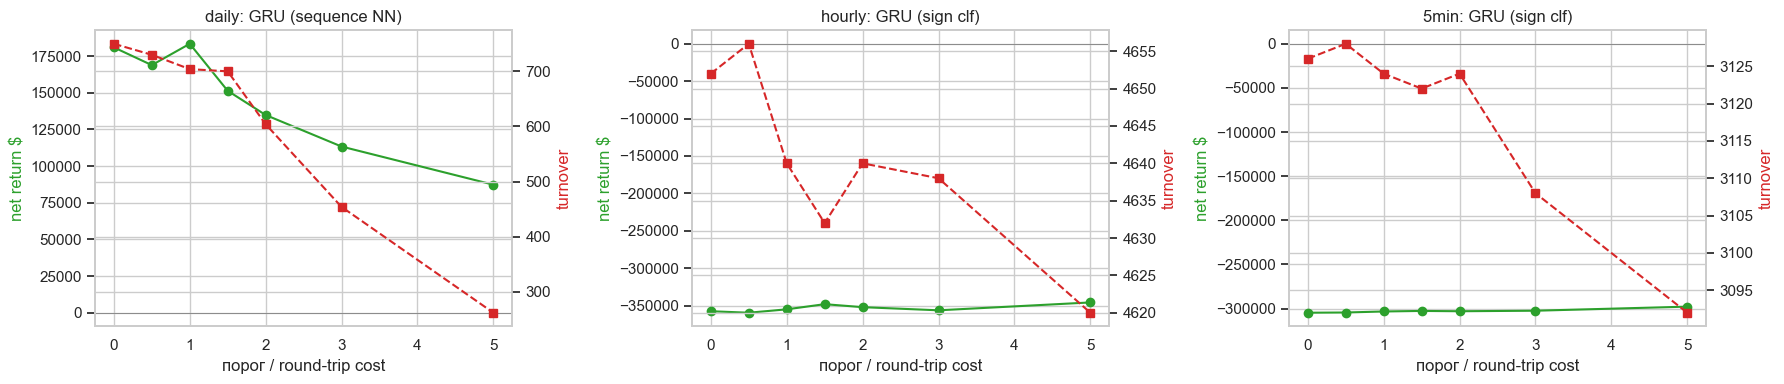


Val-tuned threshold (выбран на первых 40% OOF, оценён на остатке):


,frequency,model,thr/cost,strat_return,strat_sharpe,turnover,BH_return,BH_sharpe
0,daily,GRU (sequence NN),3.0,49060.02,0.889,176,24605.77,0.405
1,hourly,GRU (sign clf),1.5,-247837.33,-7.416,2774,-14128.56,-0.267
2,5min,GRU (sign clf),1.0,-184897.36,-84.410,1892,-17825.70,-8.051


In [14]:
# Per-fold metrics (return space). SMAPE опущена: на доходностях знаменатель
# обращается в ноль при смене знака; ведущая метрика — Directional Accuracy (DA).
# Непрерывность с прежним отчётом даёт отдельная таблица метрик на восстановленной
# ЦЕНЕ ниже.
print('Walk-forward per-fold metrics (target = log-return):')
for freq in wf_metrics_all:
    print(f'\n--- {freq} ---')
    fold_table = (wf_metrics_all[freq]
                  .sort_values(['model', 'fold'])
                  [['fold', 'model', 'MAE', 'RMSE', 'MASE', 'DA', 'AUC', 'n_train', 'n_test']])
    display(fold_table.round({'MAE': 6, 'RMSE': 6, 'MASE': 4, 'DA': 4, 'AUC': 4}))

print('\n\nWalk-forward aggregate (mean across folds, sorted by IC IR — composite lead):')
agg_display = wf_agg.sort_values(['frequency', 'IC_IR'], ascending=[True, False]).copy()
_agg_cols = ['frequency', 'model', 'family', 'MASE', 'DA', 'IC_IR', 'RankIC',
             'MWDA', 'NetSharpe', 'MCC', 'BalAcc', 'AUC']
display(agg_display[[c for c in _agg_cols if c in agg_display.columns]]
        .round({'MASE': 4, 'DA': 4, 'IC_IR': 3, 'RankIC': 4, 'MWDA': 4,
                'NetSharpe': 3, 'MCC': 4, 'BalAcc': 4, 'AUC': 4}))

# Headline: Directional Accuracy of naive + best GB + best NN per frequency.
# Опорная линия — max(base_rate, 1−base_rate) (always-majority baseline), а НЕ 0.5:
# при дрейфе BTC доля up-баров != 0.5, и честный нуль навыка = доля мажоритарного класса.
base_rate_by_freq = {}
for _freq in wf_frames:
    _r = wf_frames[_freq][TARGET].to_numpy(dtype=float)
    _r = _r[np.isfinite(_r)]
    _up = float(np.mean(_r > 0)) if _r.size else 0.5
    base_rate_by_freq[_freq] = max(_up, 1.0 - _up)
baseline_agg = wf_agg[wf_agg['family'] == 'baseline']
headline = (pd.concat([baseline_agg, best_gb, best_nn, best_nn_clf])
            .sort_values(['frequency', 'DA'], ascending=[True, False]).reset_index(drop=True))

fig, axes = plt.subplots(1, len(wf_frames), figsize=(6 * len(wf_frames), 5), sharey=False)
if len(wf_frames) == 1:
    axes = [axes]
for ax, frequency in zip(axes, wf_frames.keys()):
    subset = headline[headline['frequency'] == frequency].sort_values('DA')
    sns.barplot(data=subset, x='DA', y='model', hue='model', legend=False, ax=ax, palette='viridis')
    _naive_da = base_rate_by_freq[frequency]
    ax.axvline(_naive_da, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{frequency.title()} Directional Accuracy (walk-forward OOF)')
    ax.set_xlabel(f'DA (mean across folds); {_naive_da:.3f} = always-majority baseline')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Best model per family by composite (IC IR -> NetSharpe -> MWDA; incl. sign clf):')
_hl_cols = ['frequency', 'model', 'family', 'MASE', 'DA', 'IC_IR', 'MWDA',
            'NetSharpe', 'MCC', 'BalAcc', 'AUC']
display(headline[[c for c in _hl_cols if c in headline.columns]]
        .round({'MASE': 4, 'DA': 4, 'IC_IR': 3, 'MWDA': 4, 'NetSharpe': 3,
                'MCC': 4, 'BalAcc': 4, 'AUC': 4}))

# Price-space continuity metrics (comparable to the prior level-target SMAPE).
print('\n\nReconstructed-price error (continuity with prior report):')
display(price_metrics.sort_values(['frequency', 'SMAPE_price'])
        .round({'SMAPE_price': 4, 'MAE_price': 2}))

# -------------------------------------------------------
# Экономический бэктест: naive (порог 0) vs cost-aware (порог + гистерезис + min-hold)
# -------------------------------------------------------
from backtest import round_trip_cost, threshold_sweep, select_threshold_by_sharpe

RTC = round_trip_cost(0.0005, 2.0)        # полные издержки входа+выхода (~0.14%)
MIN_HOLD = {'daily': 2, 'hourly': 4, '5min': 6}
print(f'\n\nRound-trip cost = {RTC:.4%}. Cost-aware: вход при r_hat > RTC, выход при '
      f'r_hat < 0 (гистерезис), min-hold = {MIN_HOLD}.')

econ_rows = []
for freq, price_oof in wf_oof_price_all.items():
    ppy = PERIODS_PER_YEAR[freq]
    bh = buy_and_hold(price_oof)
    variants = {
        'thr=0 (как раньше)': dict(enter_threshold=0.0, exit_threshold=0.0, min_hold=1),
        'cost-aware':         dict(enter_threshold=RTC, exit_threshold=0.0, min_hold=MIN_HOLD[freq]),
    }
    for label, kw in variants.items():
        strat = simulate_strategy(price_oof, fee_rate=0.0005, slippage_bps=2.0, **kw)
        summ = backtest_summary(strat, bh, periods_per_year=ppy)
        st = summ[summ['type'] == 'Strategy'].copy()
        st['variant'] = label; st['frequency'] = freq
        econ_rows.append(st)
        if label == 'cost-aware':
            bo = summ[summ['type'] == 'Buy&Hold'].copy()
            bo['variant'] = 'Buy&Hold'; bo['frequency'] = freq
            econ_rows.append(bo)
econ_df = pd.concat(econ_rows, ignore_index=True)

for freq in wf_frames:
    print(f'\n--- {freq} ---')
    subset = econ_df[econ_df['frequency'] == freq].sort_values(['model', 'variant'])
    display(subset[['model', 'variant', 'total_return_usd', 'total_fees_usd',
                    'sharpe', 'max_drawdown_usd', 'turnover']]
            .round({'total_return_usd': 2, 'total_fees_usd': 2, 'sharpe': 3, 'max_drawdown_usd': 2}))

# Кривая «порог -> доход / оборот» для лучшей по DA модели каждой частоты:
# показывает, как растущий порог режет оборот (и комиссии) и где оптимум по доходу.
print('\nThreshold sweep (порог в единицах round-trip cost): net return и turnover')
_focus = (headline[headline['family'] != 'baseline']
          .sort_values('DA', ascending=False).groupby('frequency').head(1))
fig, axes = plt.subplots(1, len(wf_frames), figsize=(6 * len(wf_frames), 4))
if len(wf_frames) == 1:
    axes = [axes]
grid = np.array([0, 0.5, 1, 1.5, 2, 3, 5]) * RTC
for ax, freq in zip(axes, wf_frames.keys()):
    bm = _focus[_focus['frequency'] == freq]['model']
    if bm.empty:
        continue
    bm = bm.iloc[0]
    po = wf_oof_price_all[freq]
    po = po[po['model'] == bm]
    sw = threshold_sweep(po, thresholds=grid, periods_per_year=PERIODS_PER_YEAR[freq],
                         min_hold=MIN_HOLD[freq])
    ax2 = ax.twinx()
    ax.plot(sw['threshold'] / RTC, sw['total_return_usd'], 'o-', color='tab:green')
    ax2.plot(sw['threshold'] / RTC, sw['turnover'], 's--', color='tab:red')
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_title(f'{freq}: {bm}')
    ax.set_xlabel('порог / round-trip cost')
    ax.set_ylabel('net return $', color='tab:green')
    ax2.set_ylabel('turnover', color='tab:red')
plt.tight_layout(); plt.show()

# Порог, подобранный по net-of-cost Sharpe на ВАЛИДАЦИИ (первые 40% OOF), оценённый на
# оставшейся тест-части — без подглядывания в тестовый период.
print('\nVal-tuned threshold (выбран на первых 40% OOF, оценён на остатке):')
grid_sel = np.array([0, 0.5, 1, 1.5, 2, 3, 5, 8]) * RTC
tuned_rows = []
for freq, price_oof in wf_oof_price_all.items():
    ppy = PERIODS_PER_YEAR[freq]
    focus_models = _focus[_focus['frequency'] == freq]['model'].tolist()
    sel = select_threshold_by_sharpe(price_oof, grid_sel, periods_per_year=ppy,
                                     val_frac=0.4, min_hold=MIN_HOLD[freq])
    for model in focus_models:
        g = price_oof[price_oof['model'] == model].sort_values('timestamp')
        n_val = max(20, int(len(g) * 0.4))
        test = g.iloc[n_val:]
        thr = sel.get(model, RTC)
        strat = simulate_strategy(test, enter_threshold=thr, exit_threshold=0.0, min_hold=MIN_HOLD[freq])
        summ = backtest_summary(strat, buy_and_hold(test), periods_per_year=ppy)
        stt = summ[summ['type'] == 'Strategy'].iloc[0]
        bht = summ[summ['type'] == 'Buy&Hold'].iloc[0]
        tuned_rows.append({'frequency': freq, 'model': model, 'thr/cost': round(thr / RTC, 1),
                           'strat_return': stt['total_return_usd'], 'strat_sharpe': stt['sharpe'],
                           'turnover': stt['turnover'], 'BH_return': bht['total_return_usd'],
                           'BH_sharpe': bht['sharpe']})
display(pd.DataFrame(tuned_rows).round({'strat_return': 2, 'strat_sharpe': 3,
                                        'BH_return': 2, 'BH_sharpe': 3}))

## Two-Stage Meta-Labeling

Following the meta-labeling framework of Lopez de Prado (*Advances in Financial Machine Learning*, ch. 3), the forecast is decomposed into two stages. Stage 1 (the sequence neural network) determines the **side** of the trade, $\mathrm{sign}(\hat r)$; Stage 2 (a gradient-boosting classifier) estimates the **confidence** $p_{\mathrm{ok}} = P(\text{the bet is correct})$, which is used to size and filter trades. Stage 2 is trained strictly on the out-of-fold predictions of Stage 1, using its own causal walk-forward (purge and embargo equal to the horizon). Before deployment, a sanity gate inspects the out-of-sample rank IC of a regressor on the residual $e = r - \hat r$: if it is approximately zero, no exploitable structure remains. The table below contrasts Stage 1 (side only) with Stage 1+2 (filtering and sizing) in return space, reporting net-of-cost Sharpe, precision, and turnover.

In [15]:
# =====================================================================
# EPIC 4 — двухэтапный мета-лейблинг (Stage 1 = NN сторона, Stage 2 = GBM уверенность)
# =====================================================================
from meta_labeling import (build_meta_dataset, train_meta_walkforward,
                           meta_size, residual_sanity_gate)
from metrics import net_cost_sharpe

META_FEE = round_trip_cost(0.0005, 2.0)   # round-trip издержки для net-of-cost Sharpe

meta_rows = []
meta_oof = {}   # freq -> DataFrame(timestamp, side, p_ok, size, actual) для EPIC 5
for freq in wf_frames:
    # Stage 1 = лучшая по композиту sequence-NN (гипотеза диплома); fallback — лучший GB.
    primary = None
    if not best_nn.empty and (best_nn['frequency'] == freq).any():
        primary = best_nn[best_nn['frequency'] == freq]['model'].iloc[0]
    elif not best_gb.empty and (best_gb['frequency'] == freq).any():
        primary = best_gb[best_gb['frequency'] == freq]['model'].iloc[0]
    if primary is None:
        continue

    oof = wf_oof_all[freq]
    oof = oof[oof['model'] == primary][['timestamp', 'actual', 'predicted']].dropna()
    if oof.empty:
        continue
    feats = wf_frames[freq][TOP_FEATURES[freq]]                 # лагированные exog-фичи
    horizon = DATA_CONFIG[freq].get('horizon', 1)

    # sanity-gate (T4.5): есть ли вообще структурный остаток
    ic_res = residual_sanity_gate(oof, feats, horizon=horizon)
    if not np.isfinite(ic_res) or abs(ic_res) < 0.01:
        print(f'[{freq}] WARNING: residual Rank IC={ic_res:.3f} ~ 0 — структурного '
              f'остатка нет; мета-этап может не дать сигнала.')

    md = build_meta_dataset(oof, feats, include_pred=True)
    p_ok = train_meta_walkforward(md, horizon=horizon, n_splits=8, min_train_frac=0.3)
    size = meta_size(md.side, p_ok)
    side = md.side
    r = oof.sort_values('timestamp')['actual'].to_numpy(dtype=float)
    ppy = PERIODS_PER_YEAR[freq]

    traded = size != 0
    base_turn = int(np.sum(np.abs(np.diff(np.concatenate([[0.0], side]))) > 1e-9))
    meta_turn = int(np.sum(np.abs(np.diff(np.concatenate([[0.0], size]))) > 1e-9))
    meta_rows.append({
        'frequency': freq, 'primary (Stage 1)': primary,
        'resid_rank_ic': ic_res, 'meta_coverage': float(np.isfinite(p_ok).mean()),
        'sharpe_side': net_cost_sharpe(side, r, fee=META_FEE, ann=ppy),
        'sharpe_meta': net_cost_sharpe(size, r, fee=META_FEE, ann=ppy),
        'precision_side': float(np.mean(md.y)) if md.y.size else np.nan,
        'precision_meta': float(np.mean(md.y[traded])) if traded.any() else np.nan,
        'turnover_side': base_turn, 'turnover_meta': meta_turn,
        'trade_frac_meta': float(np.mean(traded)),
    })
    meta_oof[freq] = pd.DataFrame({'timestamp': md.timestamp, 'side': side,
                                   'p_ok': p_ok, 'size': size, 'actual': r})

meta_summary = pd.DataFrame(meta_rows)
print('Meta-labeling: Stage 1 (side only) vs Stage 1+2 (confidence filter & sizing)')
print('Гипотеза: precision_meta > precision_side и turnover_meta < turnover_side '
      '(отсечение ложных сигналов), net-of-cost Sharpe растёт.')
display(meta_summary.round({'resid_rank_ic': 3, 'meta_coverage': 2, 'sharpe_side': 3,
        'sharpe_meta': 3, 'precision_side': 3, 'precision_meta': 3, 'trade_frac_meta': 2}))

in] WARNING: residual Rank IC=-0.005 ~ 0 — структурного остатка нет; мета-этап может не дать сигнала.
Meta-labeling: Stage 1 (side only) vs Stage 1+2 (confidence filter & sizing)
Гипотеза: precision_meta > precision_side и turnover_meta < turnover_side (отсечение ложных сигналов), net-of-cost Sharpe растёт.


,frequency,primary (Stage 1),resid_rank_ic,meta_coverage,sharpe_side,sharpe_meta,precision_side,precision_meta,turnover_side,turnover_meta,trade_frac_meta
0,daily,GRU (sequence NN),0.052,0.7,1.755,1.342,0.571,0.590,752,1548,0.51
1,hourly,LSTM (sequence NN),0.055,0.7,-14.612,-15.732,0.437,0.449,6281,12163,0.49
2,5min,GRU (sequence NN),-0.005,0.7,-198.581,-182.732,0.554,0.545,6118,10253,0.67


## Position Sizing and Overfitting Control

The continuous position size produced by meta-labeling is passed to the backtest (`simulate_strategy` with costs charged on $|\Delta\text{position}|$ and short positions permitted) and compared with a binary cost-aware strategy and with Buy-and-Hold on economic criteria (Sharpe, Sortino, Calmar, and the Probabilistic Sharpe Ratio). Multiple-testing risk is controlled with the Deflated Sharpe Ratio and the Probability of Backtest Overfitting, computed from the distribution of net-of-cost Sharpe ratios across combinatorial purged cross-validation (CPCV) paths.

In [16]:
# =====================================================================
# EPIC 5 — непрерывный сайзинг в бэктесте (meta size) + Sortino/Calmar/PSR
# =====================================================================
sizing_rows = []
for freq, mo in meta_oof.items():
    prim = meta_summary.loc[meta_summary['frequency'] == freq, 'primary (Stage 1)']
    if prim.empty:
        continue
    primary = prim.iloc[0]
    po = wf_oof_price_all[freq]
    po = po[po['model'] == primary].copy()
    if po.empty:
        continue
    po['size'] = po['timestamp'].map(mo.set_index('timestamp')['size']).fillna(0.0)
    ppy = PERIODS_PER_YEAR[freq]
    bh = buy_and_hold(po)
    binary = simulate_strategy(po, fee_rate=0.0005, slippage_bps=2.0,
                               enter_threshold=RTC, exit_threshold=0.0, min_hold=MIN_HOLD[freq])
    cont = simulate_strategy(po, fee_rate=0.0005, slippage_bps=2.0, size_col='size')
    for label, strat in (('binary cost-aware', binary), ('meta size (continuous)', cont)):
        srow = backtest_summary(strat, bh, periods_per_year=ppy)
        st = srow[srow['type'] == 'Strategy'].iloc[0]
        sizing_rows.append({'frequency': freq, 'primary': primary, 'variant': label,
            'total_return_usd': st['total_return_usd'], 'sharpe': st['sharpe'],
            'sortino': st['sortino'], 'calmar': st['calmar'], 'psr': st['psr'],
            'max_drawdown_usd': st['max_drawdown_usd'], 'turnover': st['turnover']})
        if label == 'binary cost-aware':
            bo = srow[srow['type'] == 'Buy&Hold'].iloc[0]
            sizing_rows.append({'frequency': freq, 'primary': primary, 'variant': 'Buy&Hold',
                'total_return_usd': bo['total_return_usd'], 'sharpe': bo['sharpe'],
                'sortino': bo['sortino'], 'calmar': bo['calmar'], 'psr': bo['psr'],
                'max_drawdown_usd': bo['max_drawdown_usd'], 'turnover': 0})
sizing_summary = pd.DataFrame(sizing_rows)
print('Continuous meta-sizing vs binary cost-aware vs Buy&Hold (с Sortino/Calmar/PSR):')
if not sizing_summary.empty:
    display(sizing_summary.sort_values(['frequency', 'variant'])
            .round({'total_return_usd': 2, 'sharpe': 3, 'sortino': 3, 'calmar': 3,
                    'psr': 3, 'max_drawdown_usd': 2}))

Continuous meta-sizing vs binary cost-aware vs Buy&Hold (с Sortino/Calmar/PSR):


,frequency,primary,variant,total_return_usd,sharpe,sortino,calmar,psr,max_drawdown_usd,turnover
7,5min,GRU (sequence NN),Buy&Hold,-13589.83,-4.065,-5.390,-4.669,0.063,23518.81,0
6,5min,GRU (sequence NN),binary cost-aware,1374.83,1.759,0.350,4.165,0.748,2321.09,46
8,5min,GRU (sequence NN),meta size (continuous),-98778.21,-105.536,-124.009,-12.574,0.000,98979.75,2456
1,daily,GRU (sequence NN),Buy&Hold,53355.12,0.630,0.838,0.337,0.976,60798.44,0
0,daily,GRU (sequence NN),binary cost-aware,168062.07,1.637,1.687,1.182,1.000,22105.60,562
2,daily,GRU (sequence NN),meta size (continuous),88328.71,1.652,1.781,1.728,1.000,6020.69,465
4,hourly,LSTM (sequence NN),Buy&Hold,2612.63,0.232,0.255,0.159,0.638,66234.97,0
3,hourly,LSTM (sequence NN),binary cost-aware,-12401.85,-0.806,-0.167,-0.344,0.116,16370.23,90
5,hourly,LSTM (sequence NN),meta size (continuous),-55644.80,-4.237,-5.516,-0.548,0.000,58481.29,2373


In [17]:
# =====================================================================
# EPIC 5 — контроль переобучения: Deflated Sharpe & PBO по CPCV-путям
# (компьют-ёмко: C(N,k) путей × каждая GB-модель × частота; Optuna здесь не запускается)
# =====================================================================
from walk_forward import run_cpcv_gb
from metrics import deflated_sharpe, prob_backtest_overfitting

CPCV_N, CPCV_K = 6, 2          # C(6,2) = 15 backtest-путей
dsr_rows = []
for freq in wf_frames:
    frame = wf_frames[freq]
    horizon = DATA_CONFIG[freq].get('horizon', 1)
    feat = TOP_FEATURES[freq]; tk = min(WF_TOP_K, len(feat))
    cols = {}
    for gb_name, tpl in build_model_specs().items():
        cp = run_cpcv_gb(frame, TARGET, feat, gb_model_factory=(lambda t=tpl: clone(t)),
                         top_k=tk, N=CPCV_N, k=CPCV_K, horizon=horizon, fee=RTC)
        cols[gb_name] = cp.set_index('path')['net_cost_sharpe']
    mat = pd.DataFrame(cols).dropna()              # пути × модели
    if mat.shape[0] < 4 or mat.shape[1] < 2:
        continue
    model_mean = mat.mean(axis=0)
    observed = float(model_mean.max())
    dsr = deflated_sharpe(model_mean.tolist(), observed_sr=observed, T=len(frame))
    pbo = prob_backtest_overfitting(mat.to_numpy(), n_splits=6)
    dsr_rows.append({'frequency': freq, 'n_paths': mat.shape[0], 'n_models': mat.shape[1],
                     'best_gb': model_mean.idxmax(), 'sharpe_best': observed,
                     'DSR': dsr, 'PBO': pbo})
dsr_summary = pd.DataFrame(dsr_rows)
print('CPCV multiple-testing control — Deflated Sharpe Ratio & PBO (per frequency):')
print('Порог пересмотра: DSR<0.95 или PBO>0.5 -> результат вероятно переоценён.')
if not dsr_summary.empty:
    display(dsr_summary.round(3))

CPCV multiple-testing control — Deflated Sharpe Ratio & PBO (per frequency):
Порог пересмотра: DSR<0.95 или PBO>0.5 -> результат вероятно переоценён.


,frequency,n_paths,n_models,best_gb,sharpe_best,DSR,PBO
0,daily,15,3,CatBoost,0.122,1.0,0.0
1,hourly,15,3,XGBoost,-0.117,0.0,0.1
2,5min,15,3,LightGBM,-0.594,0.0,0.6


## Interpretation

Feature importance for the best gradient-boosting model at each frequency is computed with permutation importance (model-agnostic, evaluated on the test segment) and, where available, SHAP (`TreeExplainer`). For the neural model, importance is approximated by gradient-based attribution — the mean absolute gradient of the prediction with respect to each scaled exogenous feature — because the tree-based SHAP explainer does not apply to a PyTorch model. Comparing the two rankings indicates whether the gradient-boosting and neural models rely on similar predictive signals.

,frequency,model,feature,importance_mean,importance_std
0,5min,XGBoost,ret_lag1,0.0000,0.0000
1,5min,XGBoost,ret_mean5,0.0000,0.0000
2,5min,XGBoost,Litecoin,0.0000,0.0000
3,5min,XGBoost,ret_lag10,0.0000,0.0000
4,5min,XGBoost,macd_norm,0.0000,0.0000
5,5min,XGBoost,ret_lag2,0.0000,0.0000
6,5min,XGBoost,ret_std5,0.0000,0.0000
7,5min,XGBoost,p_sma20,0.0000,0.0000
8,5min,XGBoost,ret_std20,0.0000,0.0000
9,5min,XGBoost,ret_mean20,0.0000,0.0000


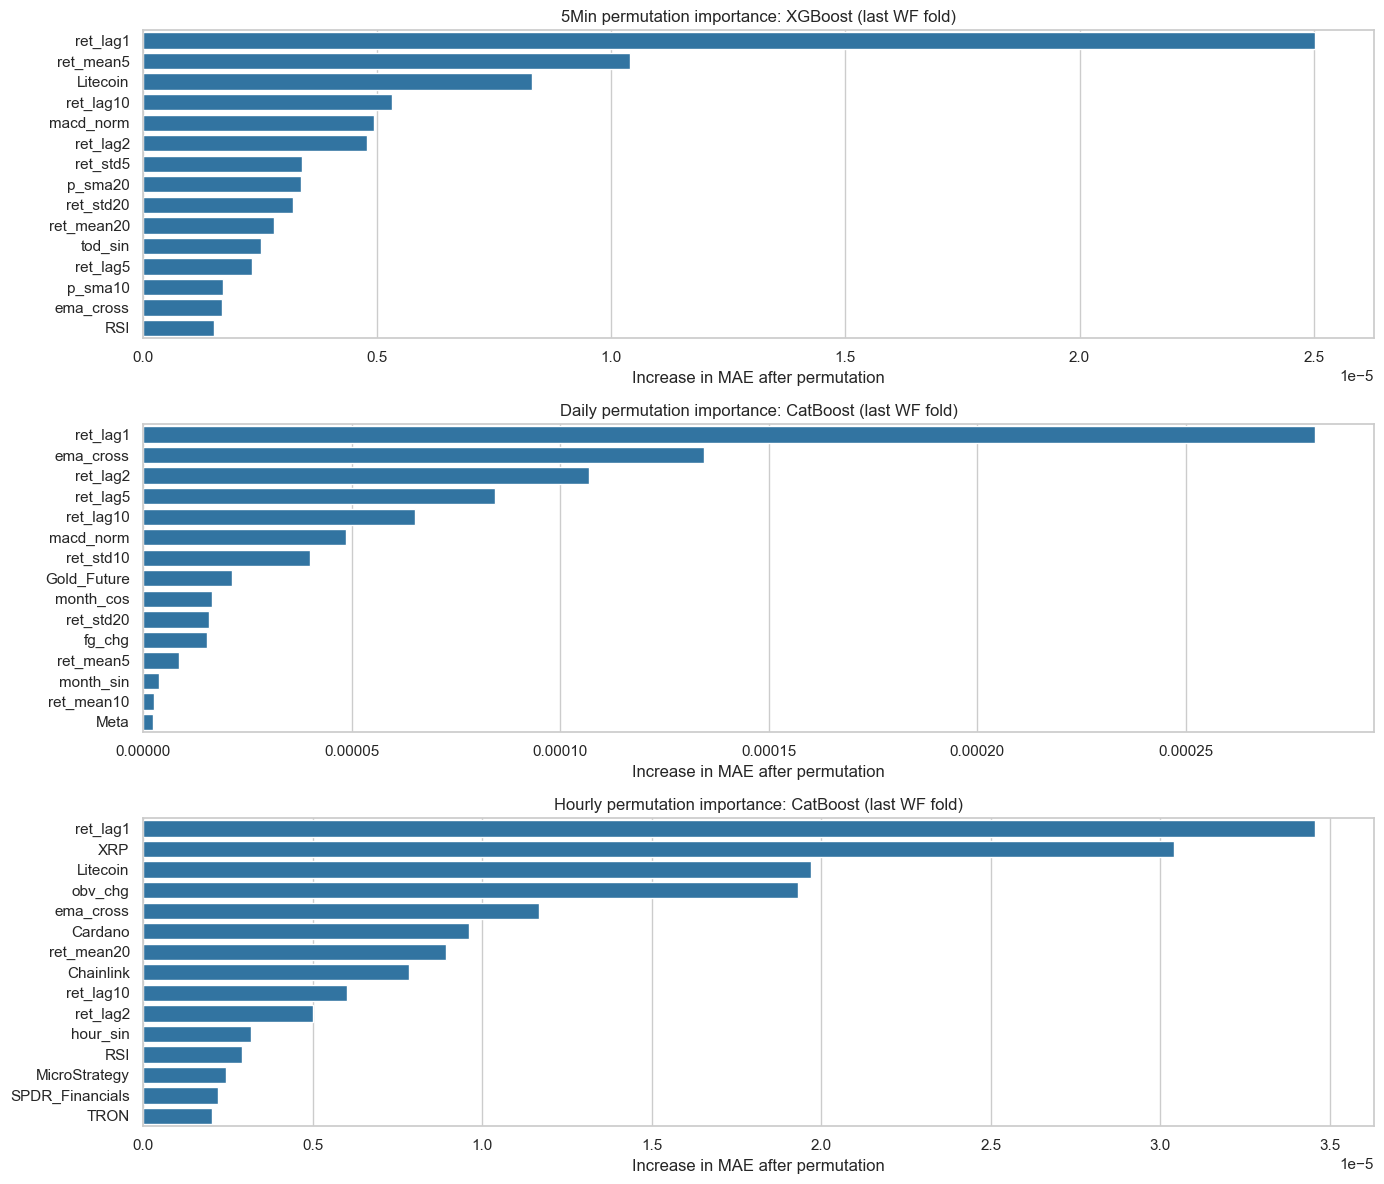

In [18]:
def permutation_importance_table(frequency, model_name, n_repeats=5, top_n=15):
    model = prediction_store[frequency][model_name]['model']
    if model is None or not hasattr(model, 'predict'):
        return pd.DataFrame()
    # Use last walk-forward fold's test data for permutation importance
    n = len(wf_frames[frequency])
    last_train_idx, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
    X_test_last = wf_frames[frequency][TOP_FEATURES[frequency]].iloc[last_test_idx]
    y_test_last = wf_frames[frequency]['BTC_logret'].iloc[last_test_idx]
    importance = permutation_importance(
        model,
        X_test_last,
        y_test_last,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error',
        n_jobs=1,
    )
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': X_test_last.columns,
        'importance_mean': importance.importances_mean,
        'importance_std': importance.importances_std,
    }).sort_values('importance_mean', ascending=False).head(top_n)
    return table

importance_tables = []
for _, row in best_gb.iterrows():
    table = permutation_importance_table(row['frequency'], row['model'])
    if not table.empty:
        importance_tables.append(table)

if importance_tables:
    importance_df = pd.concat(importance_tables, ignore_index=True)
    display(importance_df.round(4))

    fig, axes = plt.subplots(len(importance_tables), 1, figsize=(14, 4 * len(importance_tables)))
    if len(importance_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, importance_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:blue')
        frequency = table['frequency'].iloc[0]
        model_name = table['model'].iloc[0]
        ax.set_title(f'{frequency.title()} permutation importance: {model_name} (last WF fold)')
        ax.set_xlabel('Increase in MAE after permutation')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No permutation importance table was produced for the selected GB models.')


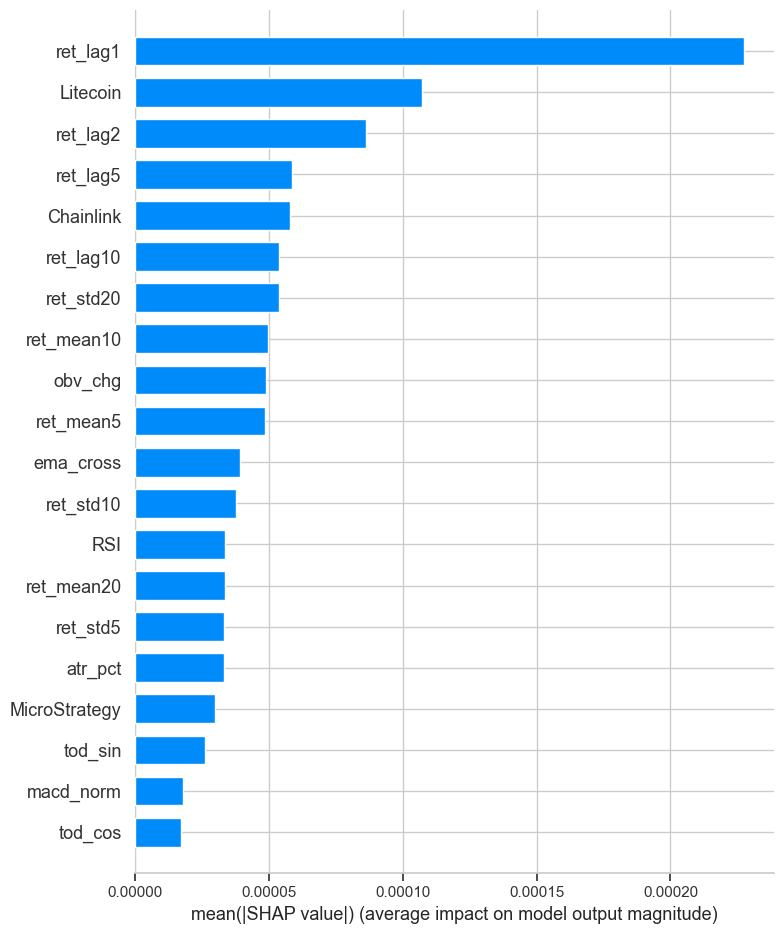

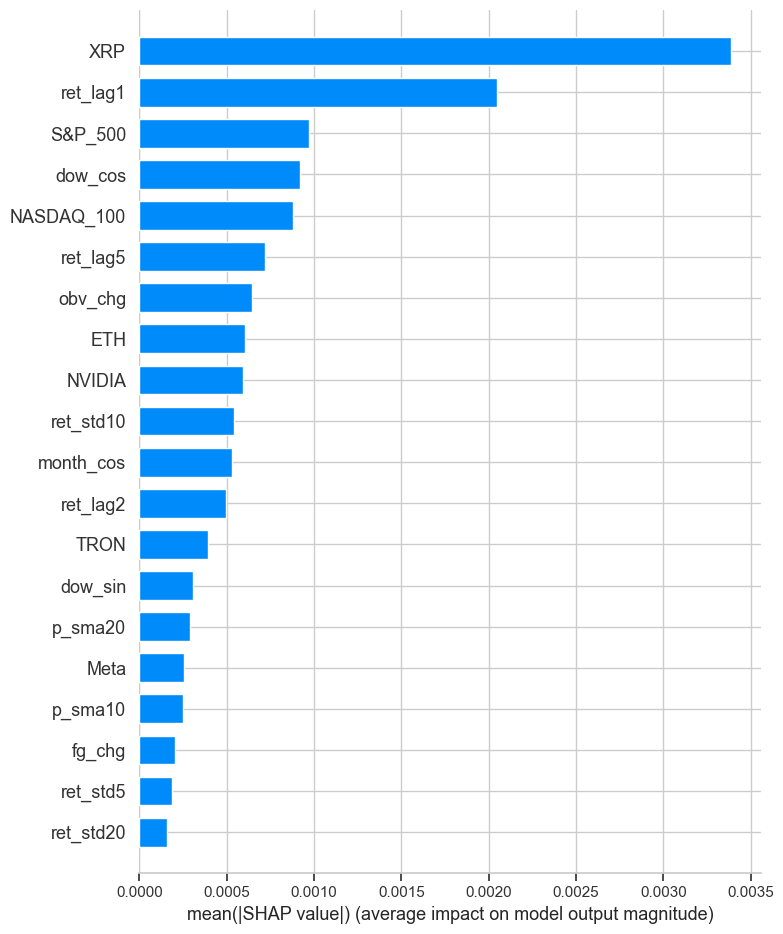

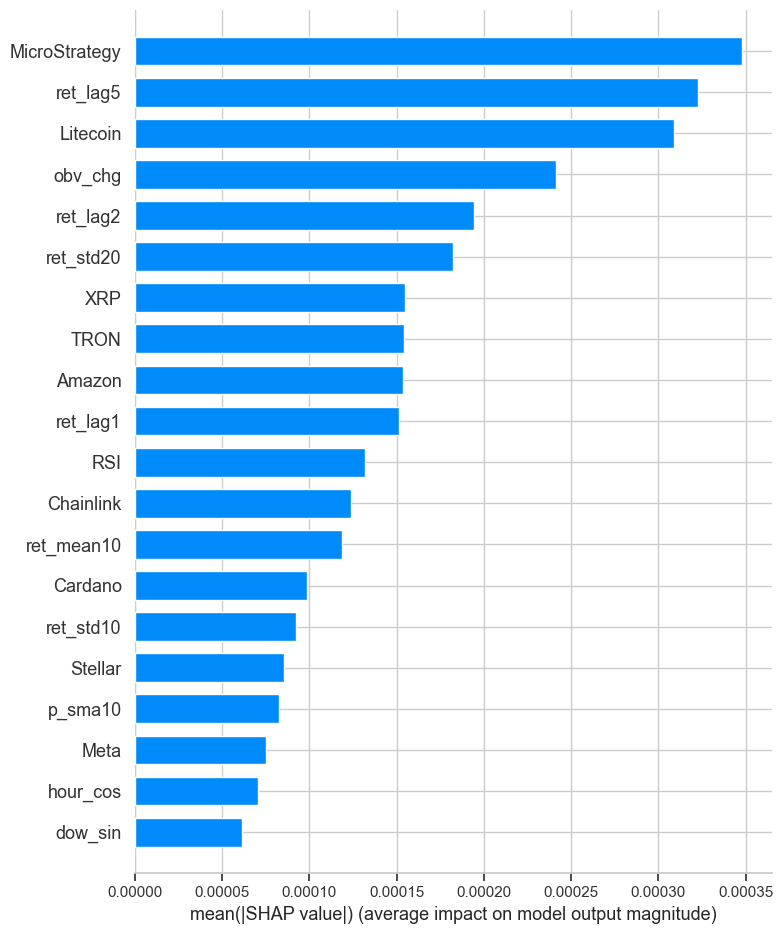

In [19]:
# SHAP interpretation for the best Gradient Boosting model per frequency.
# Uses the refit model (trained on last WF fold's train data) and that fold's test data.
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

if HAS_SHAP:
    for _, row in best_gb.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        model = prediction_store[frequency][model_name]['model']
        if model is None:
            print(f'No refit model for {frequency} {model_name}, skipping SHAP.')
            continue
        # Last WF fold test data (same as permutation importance)
        n = len(wf_frames[frequency])
        _, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
        X_test_last = wf_frames[frequency][TOP_FEATURES[frequency]].iloc[last_test_idx]
        sample = X_test_last.sample(min(500, len(X_test_last)), random_state=RANDOM_STATE)
        estimator = model.named_steps['model'] if isinstance(model, Pipeline) else model
        transformed = model[:-1].transform(sample) if isinstance(model, Pipeline) else sample
        try:
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(transformed)
            shap.summary_plot(shap_values, sample, plot_type='bar', show=True)
        except Exception as exc:
            print(f'SHAP failed for {frequency} {model_name}: {exc}')
else:
    print('SHAP is not installed in the active environment; permutation importance above is used as the reproducible interpretation method for the GB models.')


,frequency,model,feature,importance_mean,method
0,5min,GRU (sequence NN),obv_chg,0.0503,Captum IntegratedGradients
1,5min,GRU (sequence NN),dow_cos,0.0302,Captum IntegratedGradients
2,5min,GRU (sequence NN),Google,0.0284,Captum IntegratedGradients
3,5min,GRU (sequence NN),MicroStrategy,0.0235,Captum IntegratedGradients
4,5min,GRU (sequence NN),ret_lag5,0.0141,Captum IntegratedGradients
5,5min,GRU (sequence NN),p_sma10,0.0138,Captum IntegratedGradients
6,5min,GRU (sequence NN),Chainlink,0.0134,Captum IntegratedGradients
7,5min,GRU (sequence NN),ret_std10,0.0133,Captum IntegratedGradients
8,5min,GRU (sequence NN),ret_lag1,0.0130,Captum IntegratedGradients
9,5min,GRU (sequence NN),ret_std20,0.0109,Captum IntegratedGradients


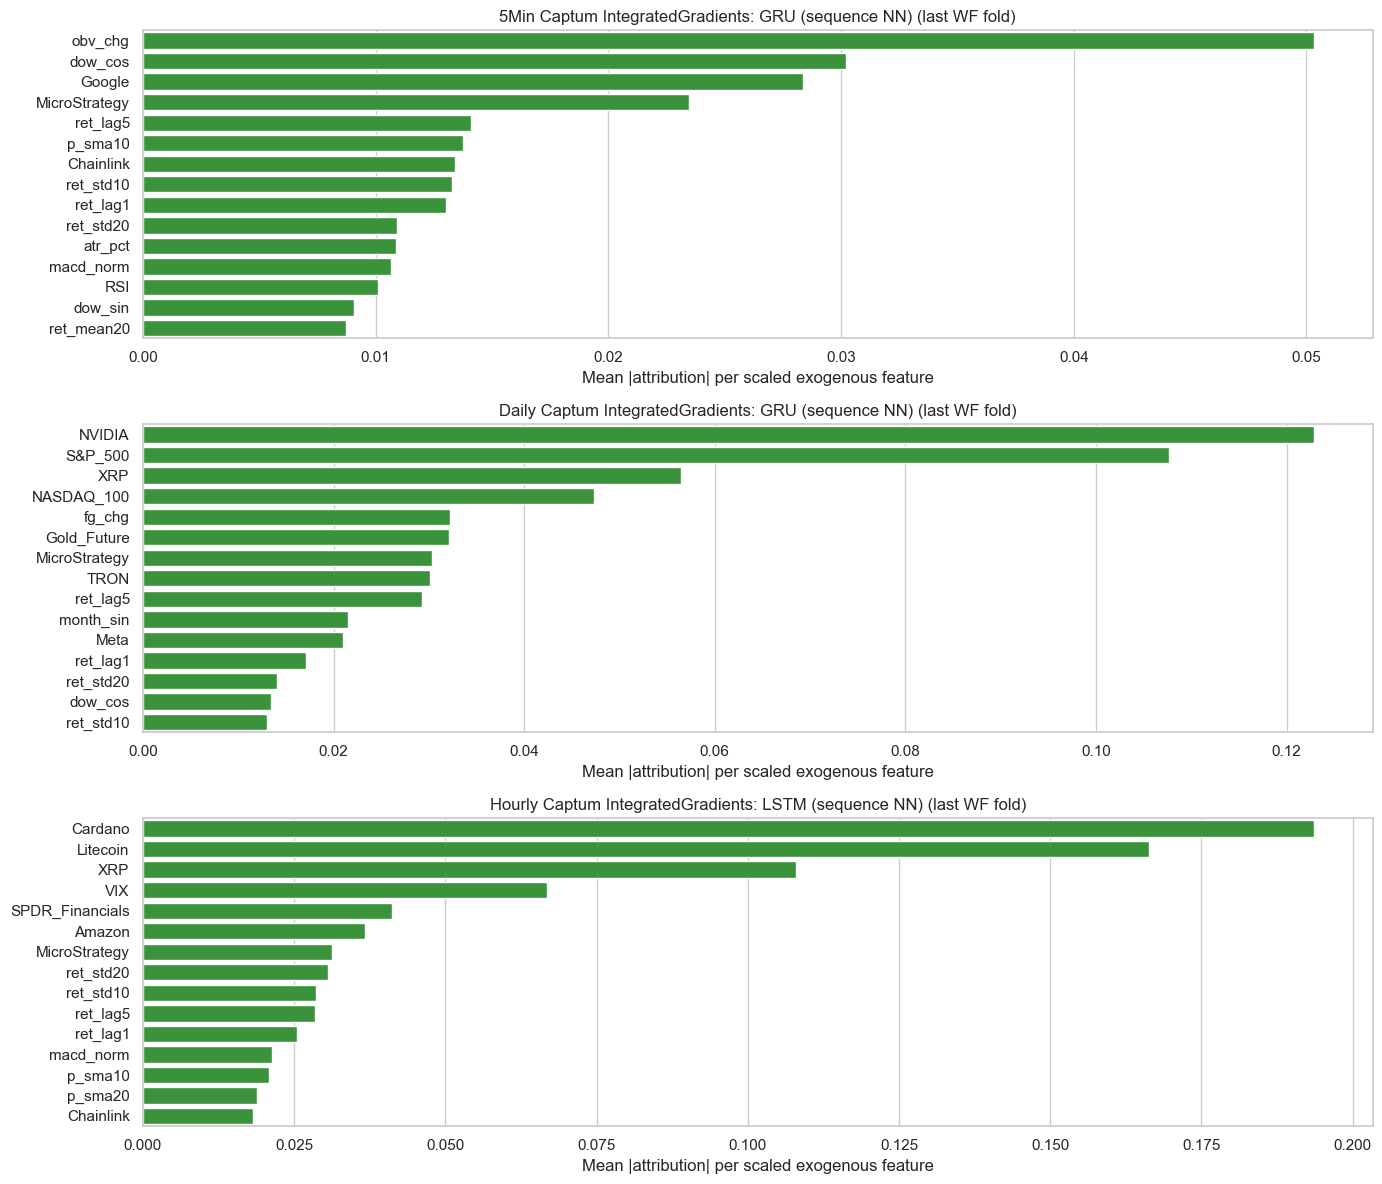

In [20]:
# Captum Integrated Gradients attribution for the best NN per frequency.
# Attributes the exogenous-feature branch of CryptoNet; the BTC-sequence branch
# is held fixed (its values are reused at every interpolation step), isolating
# the marginal contribution of each exogenous feature relative to a zero baseline.
try:
    from captum.attr import IntegratedGradients
    HAS_CAPTUM = True
except ImportError:
    HAS_CAPTUM = False

import torch

nn_attribution_tables = []
for _, row in best_nn.iterrows():
    frequency = row['frequency']
    model_name = row['model']
    reg = prediction_store[frequency][model_name]['model']
    if reg is None or not hasattr(reg, 'model_'):
        print(f'No fitted NN model available for {frequency} {model_name}, skipping.')
        continue

    # Last WF fold test data with window_size history prefix
    n = len(wf_frames[frequency])
    last_train_idx, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
    hist_start = max(0, int(last_train_idx[-1]) + 1 - reg.window_size)
    seq_test_df = wf_frames[frequency][TOP_FEATURES[frequency] + ['BTC_logret']].iloc[
        hist_start : int(last_test_idx[-1]) + 1
    ]

    X_seq, X_ex, _, _ = reg._make_windows(seq_test_df)
    X_seq_s = reg.scaler_y_.transform(X_seq.reshape(-1, 1)).reshape(X_seq.shape)
    X_ex_s = reg.scaler_x_.transform(X_ex)

    x_seq_t = torch.tensor(X_seq_s, dtype=torch.float32, device=DEVICE)
    x_ex_t = torch.tensor(X_ex_s, dtype=torch.float32, device=DEVICE)

    reg.model_.eval()

    if HAS_CAPTUM:
        # Captum IG атрибутирует ТОЛЬКО экзогенную ветвь; ветвь BTC-последовательности
        # фиксируется и передаётся как additional_forward_args, чтобы Captum размножил её
        # по n_steps интерполяции синхронно с x_ex. Замыкание над x_seq_t давало
        # рассинхрон батча (x_seq оставался B, x_ex расширялся до B*n_steps -> ошибка cat).
        def _ig_forward(x_ex, x_seq):
            return reg.model_(x_seq, x_ex).squeeze(-1)   # (N,1) -> (N,), чтобы IG не требовал target
        ig = IntegratedGradients(_ig_forward)
        attributions, convergence_delta = ig.attribute(
            x_ex_t,
            baselines=torch.zeros_like(x_ex_t),
            additional_forward_args=(x_seq_t,),
            return_convergence_delta=True,
        )
        importance = attributions.detach().abs().cpu().numpy().mean(axis=0)
        method_label = 'Captum IntegratedGradients'
    else:
        # Fallback to plain gradient attribution when captum is unavailable
        x_ex_grad = x_ex_t.clone().requires_grad_(True)
        reg.model_(x_seq_t, x_ex_grad).sum().backward()
        importance = x_ex_grad.grad.detach().abs().cpu().numpy().mean(axis=0)
        method_label = 'gradient attribution (backward)'

    feature_names = reg.feature_cols if hasattr(reg, 'feature_cols') and reg.feature_cols else TOP_FEATURES[frequency]
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': feature_names,
        'importance_mean': importance,
        'method': method_label,
    }).sort_values('importance_mean', ascending=False).head(15)
    nn_attribution_tables.append(table)

if nn_attribution_tables:
    nn_attribution_df = pd.concat(nn_attribution_tables, ignore_index=True)
    display(nn_attribution_df.round(4))

    fig, axes = plt.subplots(len(nn_attribution_tables), 1, figsize=(14, 4 * len(nn_attribution_tables)))
    if len(nn_attribution_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, nn_attribution_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:green')
        freq_lbl = table['frequency'].iloc[0]
        mname_lbl = table['model'].iloc[0]
        method_lbl = table['method'].iloc[0]
        ax.set_title(f'{freq_lbl.title()} {method_lbl}: {mname_lbl} (last WF fold)')
        ax.set_xlabel('Mean |attribution| per scaled exogenous feature')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No NN models were available for attribution.')


## Error Analysis

The residual analysis covers the best gradient-boosting model and the best neural model at each frequency. It examines the residual distribution, the temporal behaviour of the forecasts, and how forecast errors differ between calm periods and periods of sharp BTC appreciation or decline, benchmarked against the last-value baseline.

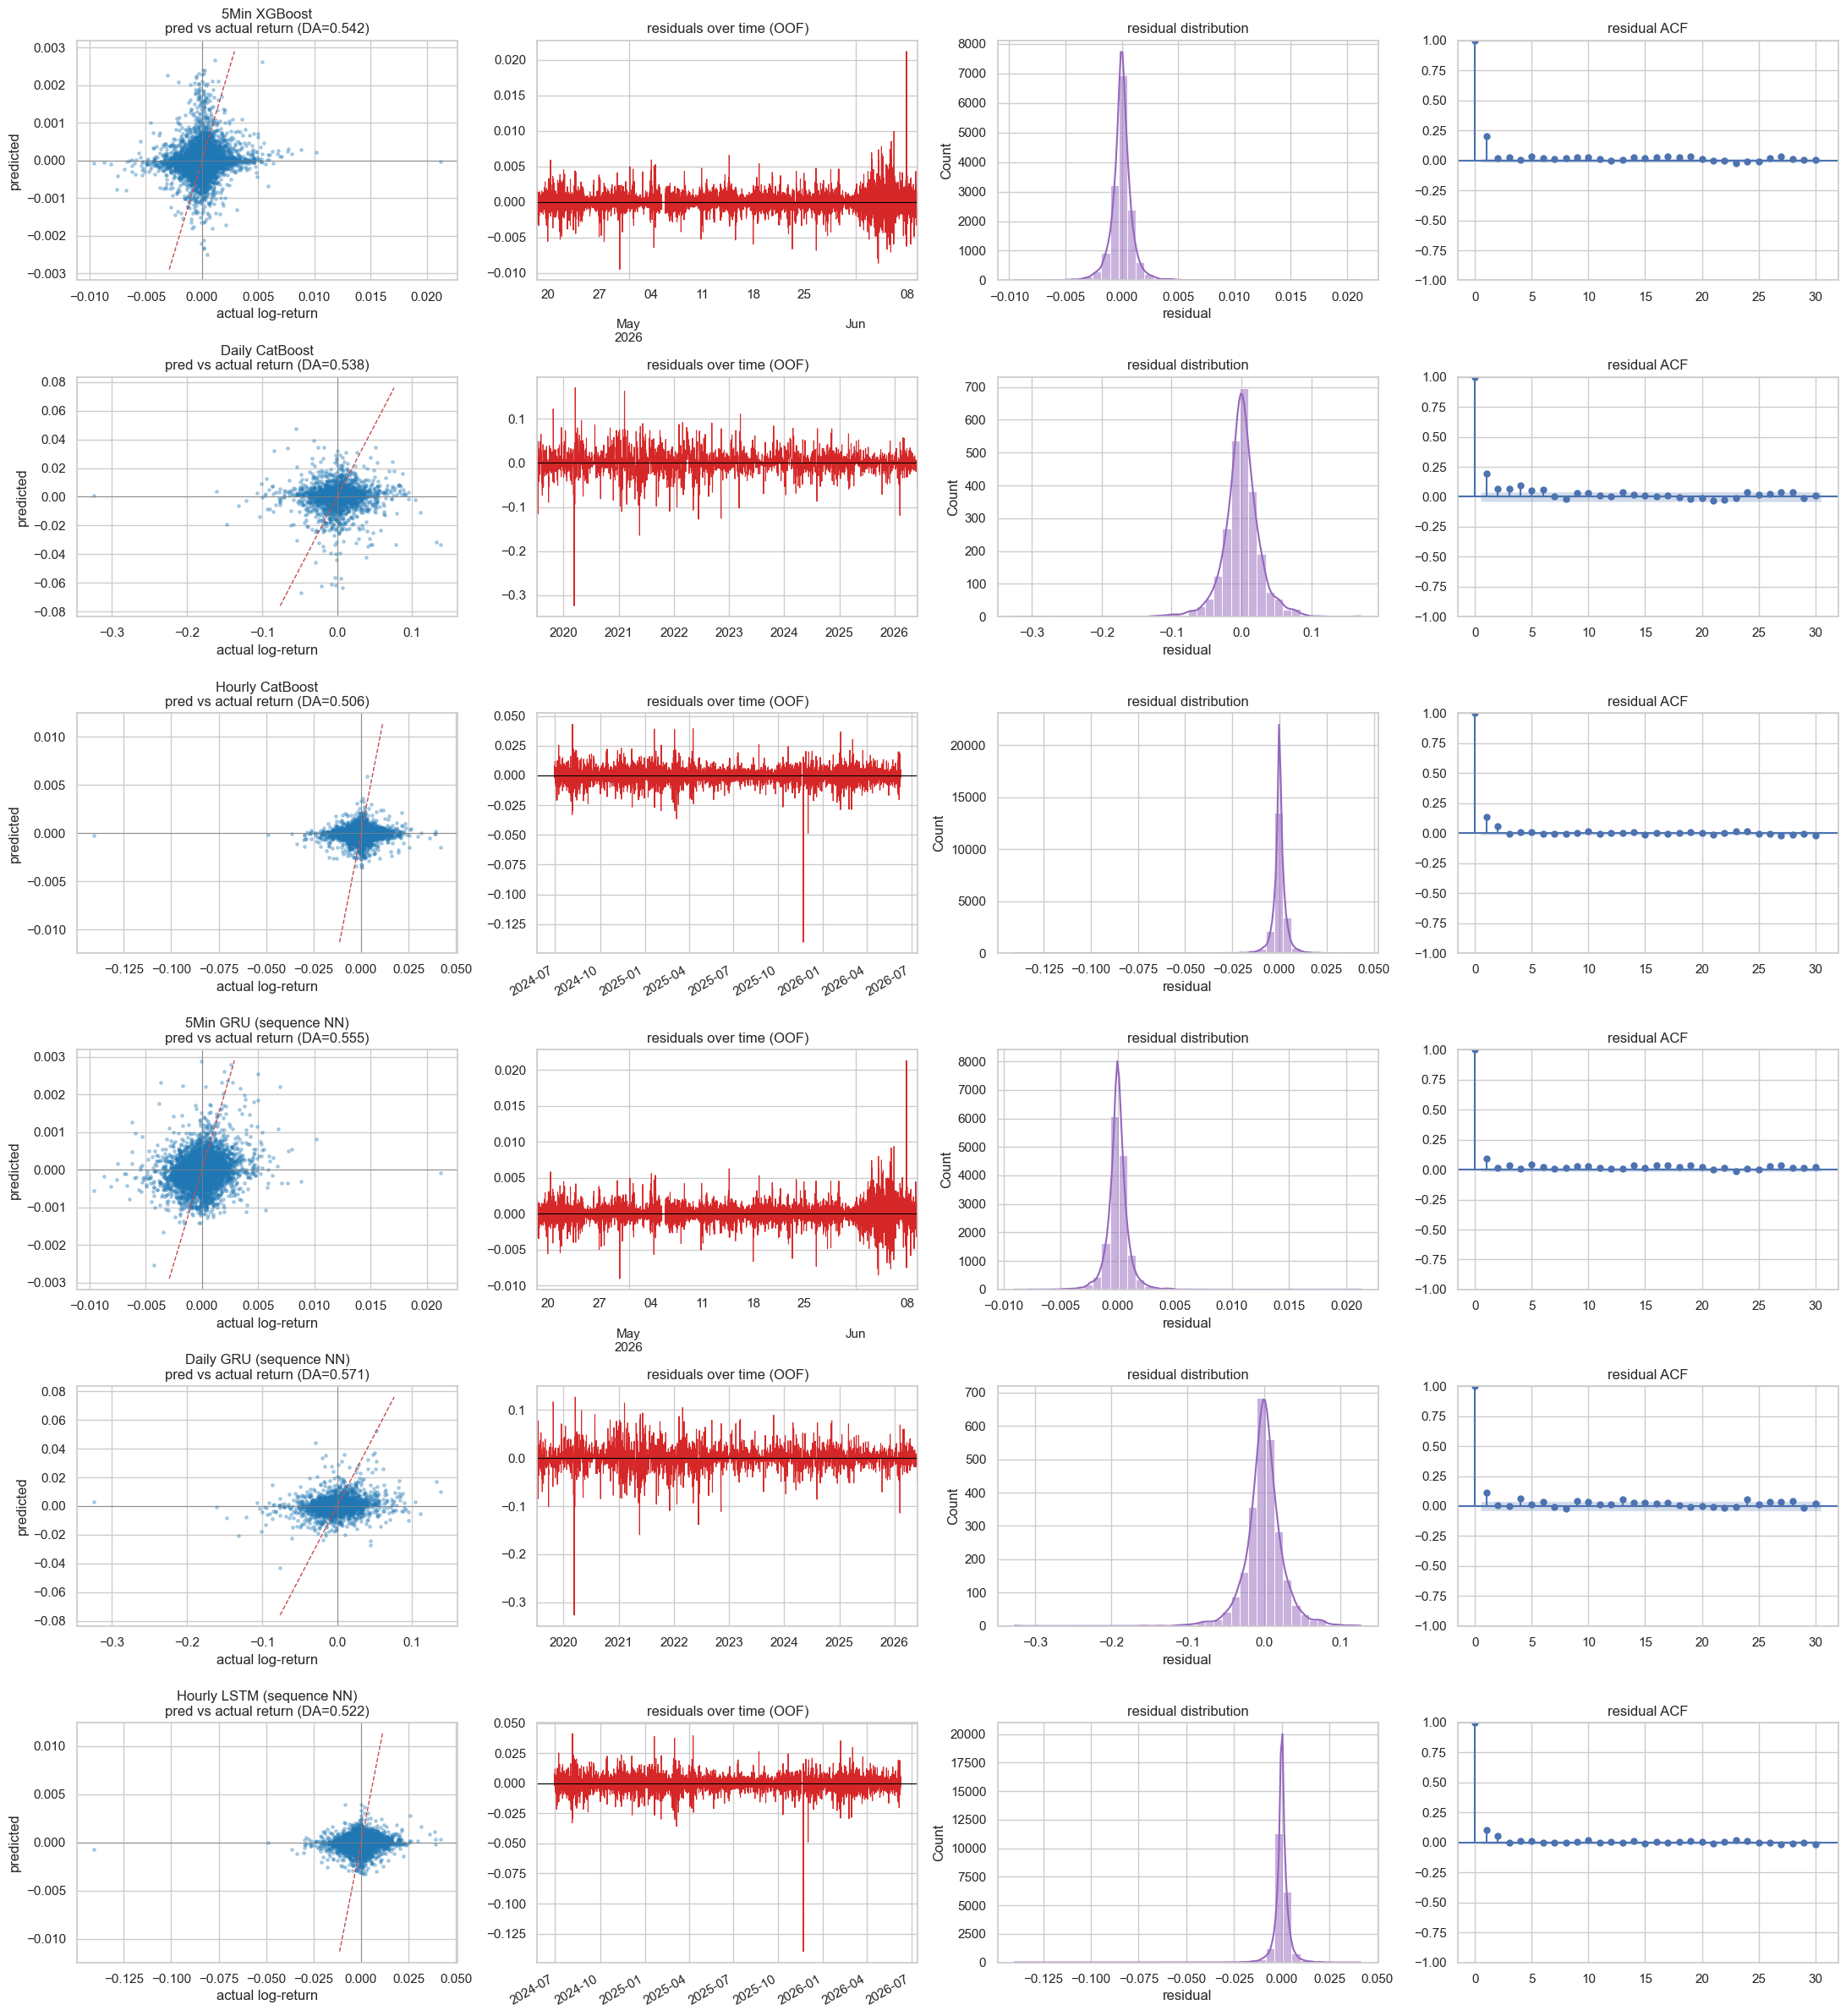

In [21]:
from statsmodels.graphics.tsaplots import plot_acf


def residual_frame(frequency, model_name):
    """Остатки из OOF-прогнозов walk-forward в пространстве ДОХОДНОСТИ.

    actual/forecast - реализованная и прогнозная лог-доходность; residual =
    actual - forecast; pct_return - сама реализованная доходность (для сегментации
    шоков в анализе ниже).
    """
    oof_pred = prediction_store[frequency][model_name]['test_pred'].sort_index().dropna()
    actual = wf_frames[frequency]['BTC_logret'].reindex(oof_pred.index)
    frame = pd.DataFrame({'actual': actual, 'forecast': oof_pred}).dropna()
    frame['residual'] = frame['actual'] - frame['forecast']
    frame['abs_error'] = frame['residual'].abs()
    frame['pct_return'] = frame['actual']
    return frame


error_analysis_rows = pd.concat([best_gb, best_nn]).reset_index(drop=True)

fig, axes = plt.subplots(len(error_analysis_rows), 4, figsize=(22, 4 * len(error_analysis_rows)))
if len(error_analysis_rows) == 1:
    axes = axes.reshape(1, -1)

for row_idx, (_, row) in enumerate(error_analysis_rows.iterrows()):
    frequency = row['frequency']
    model_name = row['model']
    frame = residual_frame(frequency, model_name)

    # (1) Прогноз vs факт ДОХОДНОСТИ: scatter с линией 45°. На уровне цены такой
    # график обманчиво идеален (прогноз ~ вчерашняя цена); на доходностях он честно
    # показывает наличие/отсутствие направленного навыка (облако вокруг 45° = навык,
    # вертикальное облако у нуля = модель почти всегда предсказывает ~0).
    ax = axes[row_idx, 0]
    ax.scatter(frame['actual'], frame['forecast'], s=6, alpha=0.3, color='tab:blue')
    lim = np.nanpercentile(np.abs(frame[['actual', 'forecast']].values), 99)
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
    ax.axhline(0, color='grey', lw=0.6)
    ax.axvline(0, color='grey', lw=0.6)
    da = float(np.mean((frame['actual'] > 0) == (frame['forecast'] > 0)))
    ax.set_title(f'{frequency.title()} {model_name}\npred vs actual return (DA={da:.3f})')
    ax.set_xlabel('actual log-return')
    ax.set_ylabel('predicted')

    # (2) Ряд остатков во времени
    frame['residual'].plot(ax=axes[row_idx, 1], color='tab:red', linewidth=0.8)
    axes[row_idx, 1].axhline(0, color='black', linewidth=0.8)
    axes[row_idx, 1].set_title('residuals over time (OOF)')
    axes[row_idx, 1].set_xlabel('')

    # (3) Распределение остатков
    sns.histplot(frame['residual'], bins=40, kde=True, ax=axes[row_idx, 2], color='tab:purple')
    axes[row_idx, 2].set_title('residual distribution')

    # (4) ACF остатков: значимая автокорреляция => модель оставила невыбранную
    # предсказуемую структуру (неполная спецификация). Белый шум => спецификация ок.
    max_lags = max(1, min(30, len(frame) // 2 - 1))
    plot_acf(frame['residual'].dropna(), ax=axes[row_idx, 3], lags=max_lags)
    axes[row_idx, 3].set_title('residual ACF')

plt.tight_layout()
plt.show()


In [22]:
# Shock-period error analysis in RETURN space.
# Сегменты OOF по величине реализованной доходности: |r| > k*std(r), k=2 (основной)
# и k=3 (проверка чувствительности). Для лучших GB/NN и бэйзлайнов считаем
# MAE/MASE/Directional Accuracy по сегментам "резкий рост"/"резкое падение"/"норма".
SHOCK_K_VALUES = [2, 3]

baseline_wf = wf_agg[wf_agg['family'] == 'baseline']
shock_candidates = pd.concat([baseline_wf, best_gb, best_nn]).reset_index(drop=True)

shock_rows = []
shock_detail_rows = []

for k in SHOCK_K_VALUES:
    for _, row in shock_candidates.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        frame = residual_frame(frequency, model_name).dropna(subset=['pct_return'])
        if frame.empty:
            continue

        ret_std = frame['pct_return'].std()
        threshold = k * ret_std
        frame = frame.copy()
        frame['shock_type'] = np.where(
            frame['pct_return'] >= threshold, 'sharp growth',
            np.where(frame['pct_return'] <= -threshold, 'sharp drop', 'normal'),
        )

        oof_start_pos = wf_frames[frequency].index.get_loc(frame.index[0])
        y_train_proxy = wf_frames[frequency]['BTC_logret'].iloc[:oof_start_pos].to_numpy(dtype=float)

        for shock_type, group in frame.groupby('shock_type'):
            metrics = regression_metrics(
                group['actual'].values, group['forecast'].values,
                y_train_proxy if len(y_train_proxy) > 1 else group['actual'].values,
            )
            shock_rows.append({
                'k': k, 'frequency': frequency, 'model': model_name,
                'period_type': shock_type,
                'threshold_ret': round(threshold, 5),
                'n_observations': len(group),
                'MAE': metrics['MAE'], 'MASE': metrics['MASE'], 'DA': metrics['DA'],
            })

        if k == 2:
            shocks = frame[frame['shock_type'] != 'normal'].copy()
            shocks['abs_ret'] = shocks['pct_return'].abs()
            for time, values in shocks.sort_values('abs_ret', ascending=False).head(10).iterrows():
                shock_detail_rows.append({
                    'frequency': frequency, 'model': model_name, 'time': time,
                    'shock_type': values['shock_type'], 'realized_return': values['pct_return'],
                    'actual_ret': values['actual'], 'forecast_ret': values['forecast'],
                    'abs_error': values['abs_error'],
                })

shock_summary = pd.DataFrame(shock_rows)
shock_details = pd.DataFrame(shock_detail_rows)

print('Shock-period error analysis (|return| > 2*std), return space:')
display(shock_summary[shock_summary['k'] == 2].drop(columns='k')
        .round({'MAE': 6, 'MASE': 4, 'DA': 4, 'threshold_ret': 5}))

print('\nSensitivity check (|return| > 3*std):')
display(shock_summary[shock_summary['k'] == 3].drop(columns='k')
        .round({'MAE': 6, 'MASE': 4, 'DA': 4, 'threshold_ret': 5}))

print('\nTop individual shocks per frequency/model (k=2):')
display(shock_details.round({'realized_return': 5, 'actual_ret': 5, 'forecast_ret': 5, 'abs_error': 5}))


Shock-period error analysis (|return| > 2*std), return space:


,frequency,model,period_type,threshold_ret,n_observations,MAE,MASE,DA
0,daily,Always long,normal,0.05199,2390,0.014268,0.5879,0.5146
1,daily,Always long,sharp drop,0.05199,59,0.081589,3.3619,0.0000
2,daily,Always long,sharp growth,0.05199,71,0.070899,2.9214,1.0000
3,daily,Base rate,normal,0.05199,2390,0.014268,0.5879,0.5151
4,daily,Base rate,sharp drop,0.05199,59,0.081589,3.3619,0.2373
...,...,...,...,...,...,...,...,...
58,daily,GRU (sequence NN),sharp drop,0.05199,59,0.078328,3.2275,0.6441
59,daily,GRU (sequence NN),sharp growth,0.05199,71,0.067837,2.7952,0.6338
60,hourly,LSTM (sequence NN),normal,0.00776,19314,0.001752,0.6376,0.5178
61,hourly,LSTM (sequence NN),sharp drop,0.00776,556,0.012116,4.4094,0.6061



Sensitivity check (|return| > 3*std):


,frequency,model,period_type,threshold_ret,n_observations,MAE,MASE,DA
63,daily,Always long,normal,0.07799,2478,0.015996,0.6591,0.5169
64,daily,Always long,sharp drop,0.07799,22,0.111242,4.5838,0.0000
65,daily,Always long,sharp growth,0.07799,20,0.093080,3.8354,1.0000
66,daily,Base rate,normal,0.07799,2478,0.015996,0.6591,0.5157
67,daily,Base rate,sharp drop,0.07799,22,0.111241,4.5837,0.3182
...,...,...,...,...,...,...,...,...
121,daily,GRU (sequence NN),sharp drop,0.07799,22,0.107476,4.4286,0.7273
122,daily,GRU (sequence NN),sharp growth,0.07799,20,0.089351,3.6817,0.6500
123,hourly,LSTM (sequence NN),normal,0.01164,19974,0.002000,0.7278,0.5201
124,hourly,LSTM (sequence NN),sharp drop,0.01164,203,0.017081,6.2167,0.6453



Top individual shocks per frequency/model (k=2):


,frequency,model,time,shock_type,realized_return,actual_ret,forecast_ret,abs_error
0,daily,Always long,2020-03-12 00:00:00,sharp drop,-0.32360,-0.32360,0.00000,0.32360
1,daily,Always long,2021-05-19 00:00:00,sharp drop,-0.16027,-0.16027,0.00000,0.16027
2,daily,Always long,2022-06-13 00:00:00,sharp drop,-0.14707,-0.14707,0.00000,0.14707
3,daily,Always long,2020-03-19 00:00:00,sharp growth,0.13723,0.13723,0.00000,0.13723
4,daily,Always long,2022-11-09 00:00:00,sharp drop,-0.13197,-0.13197,0.00000,0.13197
...,...,...,...,...,...,...,...,...
205,hourly,LSTM (sequence NN),2025-03-02 16:00:00,sharp growth,0.03858,0.03858,0.00116,0.03742
206,hourly,LSTM (sequence NN),2025-03-07 00:00:00,sharp drop,-0.03653,-0.03653,-0.00070,0.03583
207,hourly,LSTM (sequence NN),2026-02-06 01:00:00,sharp growth,0.03613,0.03613,0.00087,0.03526
208,hourly,LSTM (sequence NN),2024-08-05 01:00:00,sharp drop,-0.03406,-0.03406,-0.00112,0.03294


## Discussion

**Task formulation.** All models forecast the one-step logarithmic return $r_t = \ln(P_t) - \ln(P_{t-1})$ (or, for $h>1$, the cumulative forward return), and the price is reconstructed as $\hat P_t = P_{t-1}\,\exp(\hat r_t)$. Because the target is stationary, gradient-boosting ensembles and neural networks are compared on equal terms, free of the trend-extrapolation and metric-degeneration artefacts of level-based forecasting.

**Leakage control.** Exogenous series are lagged after all merges, respecting the publication lag of the macroeconomic (FRED) series; contemporaneous BTC-derived predictors and return features are strictly lagged; deterministic calendar and time-of-day features are not lagged. Feature selection, imputation, winsorisation, and scaling are re-estimated within each training fold, so no information from the evaluation period informs the model.

**Validation.** Gradient-boosting hyperparameters are tuned inside a nested `PurgedKFold` (overlap purging and embargo) rather than a naive `TimeSeriesSplit`, and the early-stopping and hyperparameter-selection folds of the neural models are kept disjoint. In addition to a single causal walk-forward path, combinatorial purged cross-validation (CPCV) provides a distribution of out-of-sample metrics for overfitting control.

**Model selection.** Models are ranked by a composite criterion (IC IR, then net-of-cost Sharpe, then MWDA, tie-broken by MASE) rather than by raw directional accuracy, which ignores magnitude and is benchmarked against an incorrect threshold of 0.5; the appropriate baseline is $\max(\text{base rate}, 1-\text{base rate})$. Always-long and base-rate baselines establish whether a model beats a trivial bet.

**Empirical findings.** Three results stand out.

*(i) A small, momentum-like statistical signal is present at all frequencies.* Rank IC is positive throughout (approximately 0.15-0.20 at 5-minute, 0.16 daily, and 0.09 hourly), and directional accuracy exceeds the base rate at the daily and 5-minute horizons. However, the trivial last-return predictor attains the highest IC IR at every frequency, indicating that the predictability is largely return persistence rather than a signal unique to the learned models; the neural models reproduce this signal with markedly lower turnover.

*(ii) Economic viability is confined to the daily horizon.* Net-of-cost Sharpe is positive only at the daily frequency and only for the neural models. With a round-trip cost of 0.14%, the GRU regression model attains an out-of-sample Sharpe of approximately 0.89 against 0.41 for Buy-and-Hold under a cost-aware threshold tuned on held-out data, and continuous meta-sizing achieves a comparable Sharpe with a far smaller drawdown (Calmar approximately 1.7, PSR approximately 1.0). At the hourly and 5-minute horizons every strategy is net-negative: transaction costs overwhelm the small edge, and naive sign-flipping (the zero-threshold variant) is ruinous.

*(iii) Overfitting controls confirm fragility at high frequency.* The Deflated Sharpe Ratio and PBO pass only at the daily horizon; at 5-minute the PBO exceeds 0.5, flagging the apparently high IC IR as an artefact of multiple testing rather than an exploitable edge. This is a clear illustration that statistical predictability does not imply economic tradability.

**Meta-labeling.** The second stage did not add value: the residual rank IC after Stage 1 is approximately zero, so the confidence filter does not improve net-of-cost Sharpe. This is itself informative, as it indicates that the primary model already captures most of the limited available structure.

**Architecture comparison.** Neural models, and the GRU in particular, dominate gradient boosting on this task: the best gradient-boosting Sharpe is negligible at the daily horizon and negative at higher frequencies. During sharp moves ($|r| > 2\sigma$) all models substantially under-predict the magnitude of the move, but the daily GRU recovers the direction of such moves in roughly two-thirds of cases, a modest defensive property.

**Overall.** Once leakage was removed and an economically meaningful selection criterion adopted, the only robust, tradable configuration is a daily GRU return model with cost-aware sizing. At higher frequencies no architecture exhibits a stable directional edge net of costs, consistent with weak-form market efficiency at those horizons.

## Conclusion

- The pipeline forecasts Bitcoin logarithmic returns at three sampling frequencies and compares three gradient-boosting models (LightGBM, XGBoost, CatBoost) with LSTM and GRU neural networks under a single walk-forward protocol with purging, embargo, and a per-frequency retuning cadence.
- Model selection follows a composite economic criterion (IC IR, then net-of-cost Sharpe, then MWDA, with MASE as a tie-breaker) rather than raw directional accuracy; the sign classifiers are additionally evaluated by the Matthews correlation coefficient and balanced accuracy against the base-rate benchmark.
- A two-stage meta-labeling scheme (neural side, gradient-boosting confidence), trained strictly out-of-fold, supplies a continuous position size that is gated by a residual sanity check.
- Economic evaluation reports Sortino, Calmar, and the Probabilistic Sharpe Ratio, and controls multiple testing through the Deflated Sharpe Ratio and PBO over CPCV paths; a strategy is not considered deployable if DSR < 0.95 or PBO > 0.5, irrespective of its single-path Sharpe.
- Empirically, a small momentum-like signal is detectable at all frequencies but is economically exploitable only at the daily horizon and only for the neural models: a daily GRU with cost-aware sizing beats Buy-and-Hold out of sample (Sharpe approximately 0.89 versus 0.41) with a substantially smaller drawdown, whereas the hourly and 5-minute horizons are net-negative after costs and the 5-minute results are flagged as overfit by the PBO.
- The principal methodological contribution is the elimination of look-ahead leakage and the adoption of cost-aware, multiple-testing-controlled evaluation; the principal empirical finding is that statistical predictability at high frequency does not translate into economic tradability.
- Future work: on-chain, derivatives, and order-book features; correct handling of overlapping positions at horizons $h>1$; hybrid neural-embedding-to-gradient-boosting models; and a differentiable-Sharpe training objective.